In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Assuming 'citeseer.cites' is a tab-separated file
df_cites = pd.read_csv('/content/drive/MyDrive/citeseer.cites', sep='\t', header=None, names=['source', 'target'])

# View the first few lines of the DataFrame
print(df_cites.head())


   source                  target
0  100157                  100157
1  100157                  364207
2  100157                   38848
3  100157  bradshaw97introduction
4  100157    bylund99coordinating


In [ ]:
import pandas as pd
# Assuming 'citeseer.content' is a space-separated file
df_content = pd.read_csv('/content/drive/MyDrive/citeseer.content', sep='\s+', header=None, low_memory=False)

# View the first few lines of the DataFrame
print(df_content.head())


     0     1     2     3     4     5     6     7     8     9     ...  3695  \
0  100157     0     0     0     0     0     0     0     0     0  ...     0   
1  100598     0     0     0     0     0     0     0     0     0  ...     0   
2  105684     0     1     0     0     0     0     0     0     0  ...     0   
3   11099     0     0     0     0     0     0     0     0     0  ...     0   
4  114091     0     0     0     0     0     0     0     0     0  ...     0   

   3696  3697  3698  3699  3700  3701  3702  3703    3704  
0     0     0     0     0     0     0     0     0  Agents  
1     0     0     0     0     0     0     0     0      IR  
2     0     0     0     0     0     0     0     0  Agents  
3     0     0     0     0     0     0     0     0      DB  
4     0     0     0     0     0     0     0     0      AI  

[5 rows x 3705 columns]


LOADING CITESEER , CREATING THE COMBINED SIMILARITY MATRIX AND VISUALIZING THE CORRESPONDING GRAPH

          100157    100598    101570     10227    102637    103027    104045  \
100157  1.000000  0.011359  0.000000  0.012700  0.046617  0.013577  0.012506   
100598  0.011359  1.000000  0.043386  0.022361  0.010260  0.035857  0.000000   
101570  0.000000  0.043386  1.000000  0.024254  0.011128  0.012964  0.023883   
10227   0.012700  0.022361  0.024254  1.000000  0.034412  0.013363  0.012309   
102637  0.046617  0.010260  0.011128  0.034412  0.400000  0.024526  0.045183   

          104129    105684    106003  ...  zhao98empirical  \
100157  0.034078  0.026681  0.024287  ...         0.000000   
100598  0.030000  0.011744  0.010690  ...         0.010690   
101570  0.043386  0.025477  0.023191  ...         0.023191   
10227   0.011180  0.039392  0.011952  ...         0.000000   
102637  0.030779  0.048198  0.021936  ...         0.000000   

        zhao99discriminant  zheng98integrating  zheng98stochastic  \
100157            0.000000            0.011220           0.011654   
100598  

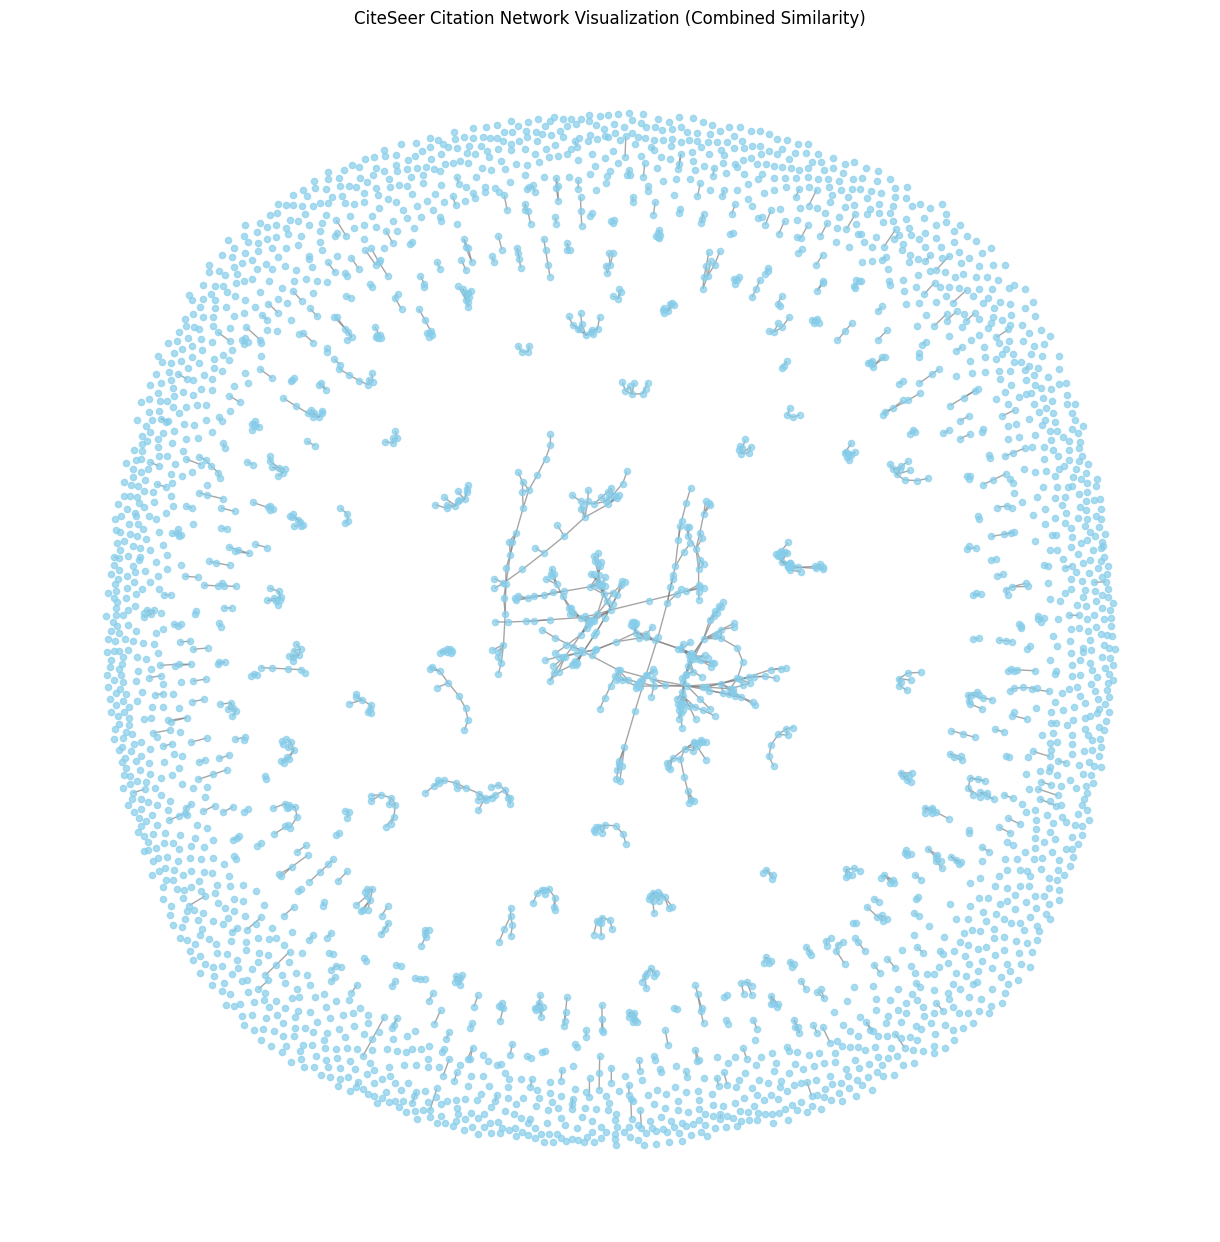

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Load the CiteSeer.cites dataset
def load_citeseer_cites(cites_file_path):
    # Read the CiteSeer.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path, sep='\t', header=None, names=['source', 'target'])
    df_sorted = df.sort_values(by='source')
    nodes = pd.unique(df_sorted[['source', 'target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['source']]
        target_idx = node_index[row['target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        jaccard_sim = intersection / (union + 1e-10)  # Avoid division by zero
        return jaccard_sim

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# Load the CiteSeer.content dataset
def load_citeseer_content(file_path):
    df = pd.read_csv(file_path, sep='\s+', header=None, low_memory=False)
    df_sorted = df.sort_values(by=0, ascending=True)
    paper_ids = df_sorted[0].values
    features = df_sorted.iloc[:, 1:-1].values  # Exclude paper_id and label columns
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids

# Paths to the datasets
cites_file_path = '/content/drive/MyDrive/citeseer.cites'
content_file_path = '/content/drive/MyDrive/citeseer.content'

# Load the similarity matrices
jaccard_sim_df, cites_nodes = load_citeseer_cites(cites_file_path)
content_sim_df, content_nodes = load_citeseer_content(content_file_path)

# Ensure the node ordering is consistent for combining similarity matrices
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))

jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# Combine the similarity matrices using the weighted sum
alpha = 0.6  # Weight for the Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values

# Convert the combined similarity matrix to a DataFrame for better readability
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

# Print the combined similarity matrix (first 5 rows for inspection)
print(combined_sim_df.head())
print(jaccard_sim_df.head())
print(content_sim_df.head())
print(f"Shape of Combined Similarity Matrix: {combined_sim_df.shape}")

# Function to construct a graph from the similarity matrix
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph from the combined similarity matrix
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# Visualize the graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, seed=42)  # Use spring layout for node positioning
nx.draw(G, pos, with_labels=False, node_size=20, node_color="skyblue", edge_color="gray", alpha=0.7)
plt.title("CiteSeer Citation Network Visualization (Combined Similarity)")
plt.show()

✅ k=3, Louvain Modularity Score: 0.9746
✅ k=4, Louvain Modularity Score: 0.9573
✅ k=5, Louvain Modularity Score: 0.9007
✅ k=6, Louvain Modularity Score: 0.8400
✅ k=7, Louvain Modularity Score: 0.7299
✅ k=8, Louvain Modularity Score: 0.4647
✅ k=9, Louvain Modularity Score: 0.0358


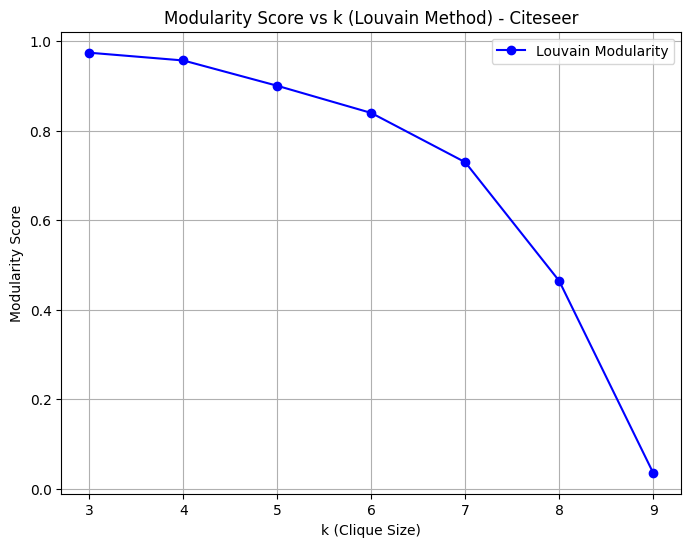

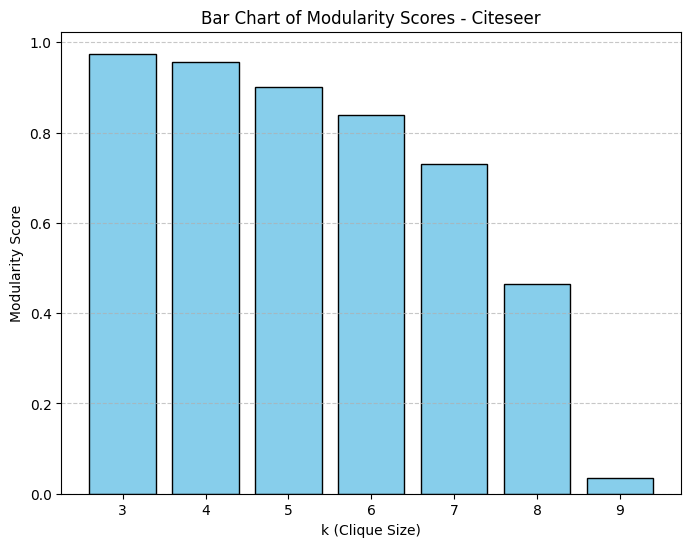

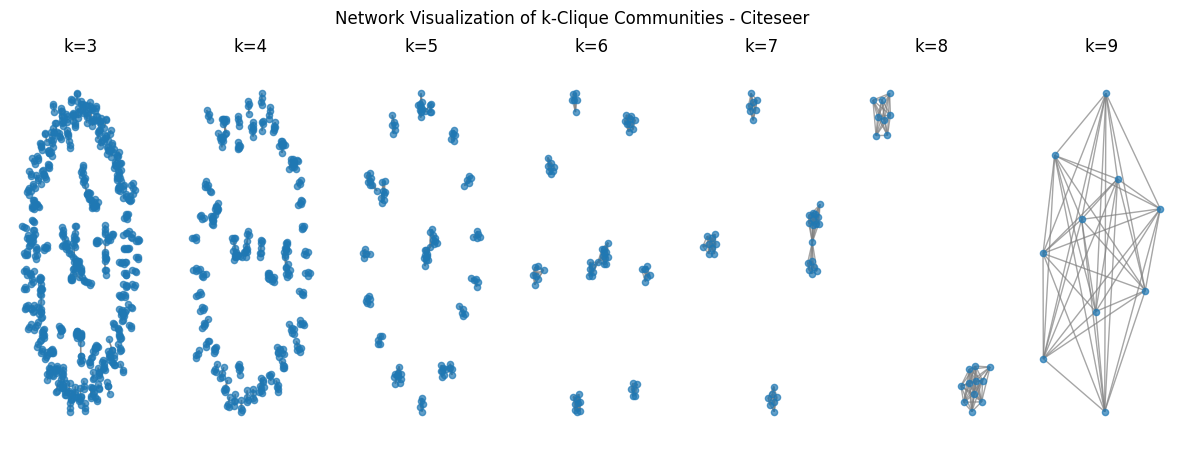

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import community.community_louvain as community  # ✅ Correct Louvain Import
from networkx.algorithms.community import k_clique_communities
import numpy as np

# ✅ Function to detect k-clique communities and compute Louvain modularity
def compute_louvain_modularity(G, k_values):
    modularity_scores = {}
    G_cliques = {}  # Store subgraphs for visualization

    for k in k_values:
        # Detect k-clique communities
        communities = list(k_clique_communities(G, k))

        # ✅ Create a subgraph with nodes in k-cliques
        G_clique = nx.Graph()
        node_community_map = {}  # Track which node belongs to which community

        for i, community_set in enumerate(communities):
            G_clique.add_nodes_from(community_set)
            for u in community_set:
                for v in community_set:
                    if u != v and G.has_edge(u, v):
                        G_clique.add_edge(u, v, weight=G[u][v].get("weight", 1))
                node_community_map[u] = i  # Assign community index to node

        # ✅ Apply Louvain community detection if there are nodes
        if G_clique.number_of_nodes() > 0:
            partition = community.best_partition(G_clique)  # ✅ Fix: Correct Louvain function
            modularity_score = community.modularity(partition, G_clique)  # ✅ Compute modularity
            modularity_scores[k] = modularity_score
            G_cliques[k] = G_clique  # Store subgraph
        else:
            modularity_scores[k] = 0  # If no communities found, modularity is 0

        print(f"✅ k={k}, Louvain Modularity Score: {modularity_scores[k]:.4f}")

    return modularity_scores, G_cliques

# ✅ Define range of k values
k_values = range(3, 10)  # k from 3 to 7

# ✅ Compute modularity scores and subgraphs
modularity_scores, G_cliques = compute_louvain_modularity(G, k_values)

# ✅ Convert dictionary to lists for plotting
modularity_values = list(modularity_scores.values())

# ✅ Visualization 1: Line Plot (Modularity vs k)
plt.figure(figsize=(8, 6))
plt.plot(k_values, modularity_values, marker='o', linestyle='-', color='b', label="Louvain Modularity")
plt.xlabel("k (Clique Size)")
plt.ylabel("Modularity Score")
plt.title("Modularity Score vs k (Louvain Method) - Citeseer")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

# ✅ Visualization 2: Bar Chart (Modularity Comparison)
plt.figure(figsize=(8, 6))
plt.bar(k_values, modularity_values, color="skyblue", edgecolor="black")
plt.xlabel("k (Clique Size)")
plt.ylabel("Modularity Score")
plt.title("Bar Chart of Modularity Scores - Citeseer")
plt.xticks(k_values)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# ✅ Visualization 3: Network Visualization of k-Clique Communities
fig, axes = plt.subplots(1, len(k_values), figsize=(15, 5))

for i, k in enumerate(k_values):
    if G_cliques[k].number_of_nodes() > 0:  # Ensure there is a subgraph
        ax = axes[i]
        pos = nx.spring_layout(G_cliques[k], seed=42)
        nx.draw(G_cliques[k], pos, ax=ax, node_size=20, edge_color="gray", alpha=0.7)
        ax.set_title(f"k={k}")

plt.suptitle("Network Visualization of k-Clique Communities - Citeseer")
plt.show()


GAT IMPLEMENTATION WITHOUT ANY NOVELTY

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# ✅ **Load CiteSeer.cites Dataset**
def load_citeseer_cites(cites_file_path):
    # Read the CiteSeer.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path, sep='\t', header=None, names=['source', 'target'])
    df_sorted = df.sort_values(by='source')
    nodes = pd.unique(df_sorted[['source', 'target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['source']]
        target_idx = node_index[row['target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        jaccard_sim = intersection / (union + 1e-10)  # Avoid division by zero
        return jaccard_sim

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# ✅ **Load CiteSeer.content Dataset**
def load_citeseer_content(file_path):
    df = pd.read_csv(file_path, sep='\s+', header=None, low_memory=False)
    df_sorted = df.sort_values(by=0, ascending=True)
    paper_ids = df_sorted[0].values  # First column: Paper IDs
    features = df_sorted.iloc[:, 1:-1].values  # Middle columns: Features
    labels = df_sorted.iloc[:, -1].values  # Last column: Labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# ✅ **Construct Graph from Combined Similarity Matrix**
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# ✅ **Convert to PyTorch Geometric Format**
def convert_to_pyg(G, node_index, features, labels):
    data = from_networkx(G)

    node_list = list(G.nodes())

    # Map node indices to feature vectors
    feature_indices = [node_index[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # Convert labels to numerical values
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index[node]]] for node in node_list])

    data.x = node_features
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data

# ✅ **Define GAT Model**
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        embeddings = x  # Second-to-last layer embeddings
        x = self.conv2(x, edge_index)
        return x, embeddings

# ✅ **Train the Model**
def train(model, data, train_mask, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out, _ = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# ✅ **Test the Model**
@torch.no_grad()
def test(model, data, train_mask, test_mask):
    model.eval()
    out, _ = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# ✅ **Compute Evaluation Metrics**
def compute_metrics(graph, embeddings, cluster_labels, true_labels):
    # Modularity
    def compute_modularity(graph, cluster_labels):
        modularity = 0.0
        m = graph.number_of_edges()
        for cluster in set(cluster_labels):
            nodes_in_cluster = [node for node, cl in enumerate(cluster_labels) if cl == cluster]
            subgraph = graph.subgraph(nodes_in_cluster)
            l_c = subgraph.number_of_edges()
            d_c = sum(dict(graph.degree(nodes_in_cluster)).values())
            modularity += (l_c / m) - (d_c / (2 * m)) ** 2
        return modularity

    # Conductance
    def compute_conductance(graph, cluster_labels):
        conductance = 0.0
        for cluster in set(cluster_labels):
            nodes_in_cluster = [node for node, cl in enumerate(cluster_labels) if cl == cluster]
            subgraph = graph.subgraph(nodes_in_cluster)
            cut_size = nx.cut_size(graph, nodes_in_cluster)
            volume = sum(dict(graph.degree(nodes_in_cluster)).values())
            if volume > 0:
                conductance += cut_size / volume
        return conductance / len(set(cluster_labels))

    modularity = compute_modularity(graph, cluster_labels)
    conductance = compute_conductance(graph, cluster_labels)
    clustering_coefficient = nx.average_clustering(graph)
    silhouette = silhouette_score(embeddings, cluster_labels)
    nmi = normalized_mutual_info_score(true_labels, cluster_labels)
    ari = adjusted_rand_score(true_labels, cluster_labels)

    return {
        "Modularity": modularity,
        "Conductance": conductance,
        "Clustering Coefficient": clustering_coefficient,
        "Silhouette Score": silhouette,
        "NMI": nmi,
        "ARI": ari
    }

# ✅ **Main Workflow**
def main():
    # Paths to datasets
    cites_file_path = '/content/drive/MyDrive/citeseer.cites'
    content_file_path = '/content/drive/MyDrive/citeseer.content'

    # Load datasets
    jaccard_sim_df, cites_nodes = load_citeseer_cites(cites_file_path)
    content_sim_df, content_nodes, features, labels = load_citeseer_content(content_file_path)

    # Ensure consistent node ordering
    common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
    jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
    content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

    # Combine similarity matrices
    alpha = 0.6  # Weight for Jaccard similarity
    combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
    combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

    # Construct graph
    threshold = 0.2  # Adjust based on required edge density
    G = construct_graph(combined_sim_df, threshold)

    # Convert to PyTorch Geometric format
    node_index = {node: idx for idx, node in enumerate(common_nodes)}
    data_pyg = convert_to_pyg(G, node_index, features, labels)

    # Train/Test split
    num_nodes = data_pyg.num_nodes
    train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
    train_mask[train_nodes] = True
    test_mask[test_nodes] = True

    # Define model, optimizer, and loss function
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_pyg = data_pyg.to(device)
    model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    # Train the model
    for epoch in range(100):
        loss = train(model, data_pyg, train_mask, optimizer, criterion)
        if epoch % 10 == 0:
            acc_train, acc_test = test(model, data_pyg, train_mask, test_mask)
            print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")

    # Extract second-to-last layer embeddings
    @torch.no_grad()
    def get_embeddings():
        model.eval()
        _, embeddings = model(data_pyg.x, data_pyg.edge_index)
        return embeddings.cpu().numpy()

    embeddings = get_embeddings()

    # Apply k-means clustering
    kmeans = KMeans(n_clusters=len(set(labels)), random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Compute evaluation metrics
    metrics = compute_metrics(G, embeddings, cluster_labels, data_pyg.y.cpu().numpy())

    # Print metrics
    print("\n🔹 Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"🔹 {metric}: {value:.4f}")

# Run the main workflow
if __name__ == "__main__":
    main()

Epoch 0: Loss: 1.8202, Train Acc: 0.5829, Test Acc: 0.5309
Epoch 10: Loss: 1.1444, Train Acc: 0.8769, Test Acc: 0.7632
Epoch 20: Loss: 0.9652, Train Acc: 0.9275, Test Acc: 0.7406
Epoch 30: Loss: 0.9538, Train Acc: 0.9385, Test Acc: 0.7270
Epoch 40: Loss: 0.9055, Train Acc: 0.9445, Test Acc: 0.7330
Epoch 50: Loss: 0.8827, Train Acc: 0.9449, Test Acc: 0.7285
Epoch 60: Loss: 0.8770, Train Acc: 0.9453, Test Acc: 0.7300
Epoch 70: Loss: 0.8812, Train Acc: 0.9487, Test Acc: 0.7315
Epoch 80: Loss: 0.8953, Train Acc: 0.9475, Test Acc: 0.7300
Epoch 90: Loss: 0.8641, Train Acc: 0.9487, Test Acc: 0.7300

🔹 Evaluation Metrics:
🔹 Modularity: 0.0000
🔹 Conductance: 0.0000
🔹 Clustering Coefficient: 0.1611
🔹 Silhouette Score: 0.2893
🔹 NMI: 0.7386
🔹 ARI: 0.7809


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# ✅ **Load CiteSeer.cites Dataset**
def load_citeseer_cites(cites_file_path):
    # Read the CiteSeer.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path, sep='\t', header=None, names=['source', 'target'])
    df_sorted = df.sort_values(by='source')
    nodes = pd.unique(df_sorted[['source', 'target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['source']]
        target_idx = node_index[row['target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        jaccard_sim = intersection / (union + 1e-10)  # Avoid division by zero
        return jaccard_sim

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# ✅ **Load CiteSeer.content Dataset**
def load_citeseer_content(file_path):
    df = pd.read_csv(file_path, sep='\s+', header=None, low_memory=False)
    df_sorted = df.sort_values(by=0, ascending=True)
    paper_ids = df_sorted[0].values  # First column: Paper IDs
    features = df_sorted.iloc[:, 1:-1].values  # Middle columns: Features
    labels = df_sorted.iloc[:, -1].values  # Last column: Labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# ✅ **Construct Graph from Combined Similarity Matrix**
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# ✅ **Convert to PyTorch Geometric Format**
def convert_to_pyg(G, node_index, features, labels):
    data = from_networkx(G)

    node_list = list(G.nodes())

    # Map node indices to feature vectors
    feature_indices = [node_index[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # Convert labels to numerical values
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index[node]]] for node in node_list])

    data.x = node_features
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data

# ✅ **Define GAT Model**
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        embeddings = x  # Second-to-last layer embeddings
        x = self.conv2(x, edge_index)
        return x, embeddings

# ✅ **Train the Model**
def train(model, data, train_mask, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out, _ = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# ✅ **Test the Model**
@torch.no_grad()
def test(model, data, train_mask, test_mask):
    model.eval()
    out, _ = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# ✅ **Compute Evaluation Metrics**
def compute_metrics(graph, embeddings, cluster_labels, true_labels):
    # Modularity
    def compute_modularity(graph, cluster_labels):
        modularity = 0.0
        m = graph.number_of_edges()
        for cluster in set(cluster_labels):
            nodes_in_cluster = [node for node, cl in enumerate(cluster_labels) if cl == cluster]
            subgraph = graph.subgraph(nodes_in_cluster)
            l_c = subgraph.number_of_edges()
            d_c = sum(dict(graph.degree(nodes_in_cluster)).values())
            modularity += (l_c / m) - (d_c / (2 * m)) ** 2
        return modularity

    # Conductance
    def compute_conductance(graph, cluster_labels):
        conductance = 0.0
        for cluster in set(cluster_labels):
            nodes_in_cluster = [node for node, cl in enumerate(cluster_labels) if cl == cluster]
            subgraph = graph.subgraph(nodes_in_cluster)
            cut_size = nx.cut_size(graph, nodes_in_cluster)
            volume = sum(dict(graph.degree(nodes_in_cluster)).values())
            if volume > 0:
                conductance += cut_size / volume
        return conductance / len(set(cluster_labels))

    modularity = compute_modularity(graph, cluster_labels)
    conductance = compute_conductance(graph, cluster_labels)
    clustering_coefficient = nx.average_clustering(graph)
    silhouette = silhouette_score(embeddings, cluster_labels)
    nmi = normalized_mutual_info_score(true_labels, cluster_labels)
    ari = adjusted_rand_score(true_labels, cluster_labels)

    return {
        "Modularity": modularity,
        "Conductance": conductance,
        "Clustering Coefficient": clustering_coefficient,
        "Silhouette Score": silhouette,
        "NMI": nmi,
        "ARI": ari
    }

# ✅ **Main Workflow**
def main():
    # Paths to datasets
    cites_file_path = '/content/drive/MyDrive/citeseer.cites'
    content_file_path = '/content/drive/MyDrive/citeseer.content'

    # Load datasets
    jaccard_sim_df, cites_nodes = load_citeseer_cites(cites_file_path)
    content_sim_df, content_nodes, features, labels = load_citeseer_content(content_file_path)

    # Ensure consistent node ordering
    common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
    jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
    content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

    # Combine similarity matrices
    alpha = 0.6  # Weight for Jaccard similarity
    combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
    combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

    # Construct graph
    threshold = 0.2  # Adjust based on required edge density
    G = construct_graph(combined_sim_df, threshold)

    # Convert to PyTorch Geometric format
    node_index = {node: idx for idx, node in enumerate(common_nodes)}
    data_pyg = convert_to_pyg(G, node_index, features, labels)

    # Train/Test split
    num_nodes = data_pyg.num_nodes
    train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
    train_mask[train_nodes] = True
    test_mask[test_nodes] = True

    # Define model, optimizer, and loss function
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_pyg = data_pyg.to(device)
    model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    # Train the model
    for epoch in range(100):
        loss = train(model, data_pyg, train_mask, optimizer, criterion)
        if epoch % 10 == 0:
            acc_train, acc_test = test(model, data_pyg, train_mask, test_mask)
            print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")

    # Extract second-to-last layer embeddings
    @torch.no_grad()
    def get_embeddings():
        model.eval()
        _, embeddings = model(data_pyg.x, data_pyg.edge_index)
        return embeddings.cpu().numpy()

    embeddings = get_embeddings()

    # Apply k-means clustering
    kmeans = KMeans(n_clusters=len(set(labels)), random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Compute evaluation metrics
    metrics = compute_metrics(G, embeddings, cluster_labels, data_pyg.y.cpu().numpy())

    # Print metrics
    print("\n🔹 Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"🔹 {metric}: {value:.4f}")

# Run the main workflow
if __name__ == "__main__":
    main()

Epoch 0: Loss: 1.8334, Train Acc: 0.5410, Test Acc: 0.4932
Epoch 10: Loss: 1.1564, Train Acc: 0.8777, Test Acc: 0.7602
Epoch 20: Loss: 0.9855, Train Acc: 0.9234, Test Acc: 0.7466
Epoch 30: Loss: 0.9426, Train Acc: 0.9415, Test Acc: 0.7406
Epoch 40: Loss: 0.9456, Train Acc: 0.9449, Test Acc: 0.7421
Epoch 50: Loss: 0.9090, Train Acc: 0.9464, Test Acc: 0.7300
Epoch 60: Loss: 0.9048, Train Acc: 0.9456, Test Acc: 0.7330
Epoch 70: Loss: 0.9032, Train Acc: 0.9490, Test Acc: 0.7345
Epoch 80: Loss: 0.8881, Train Acc: 0.9494, Test Acc: 0.7421
Epoch 90: Loss: 0.8784, Train Acc: 0.9483, Test Acc: 0.7391

🔹 Evaluation Metrics:
🔹 Modularity: 0.0000
🔹 Conductance: 0.0000
🔹 Clustering Coefficient: 0.1611
🔹 Silhouette Score: 0.2917
🔹 NMI: 0.7350
🔹 ARI: 0.7794


VISUALIZATION

🔹 k-Clique Membership Distribution:
In k-Clique (1): 123
Not in k-Clique (0): 3189


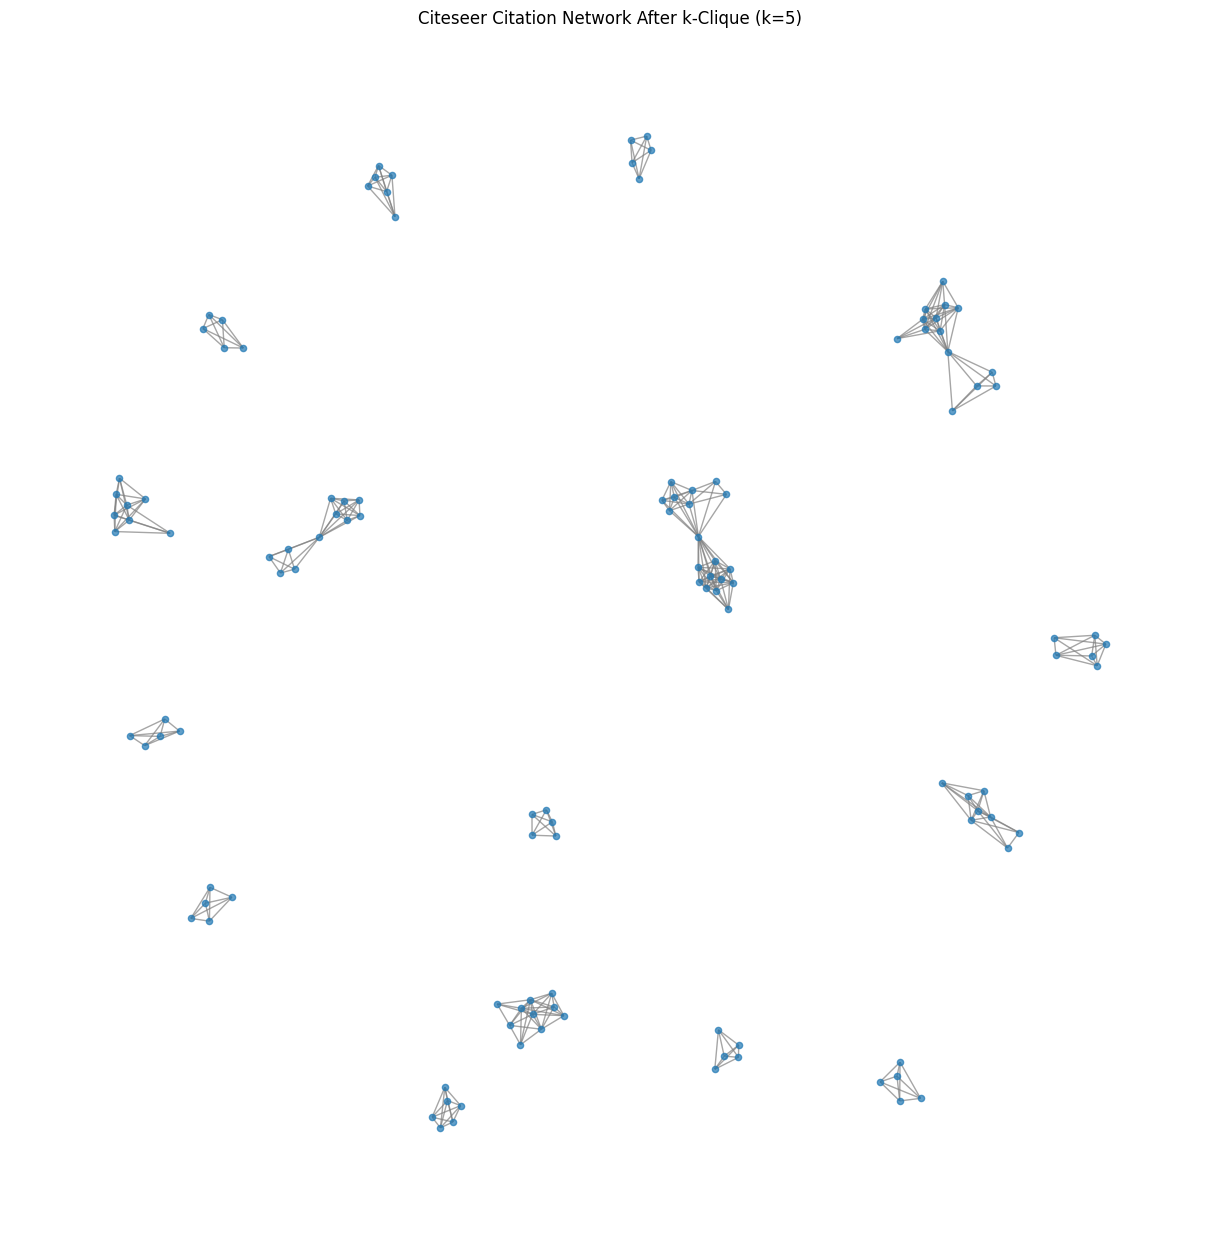

✅ Number of nodes in G_clique: 123
✅ Number of edges in G_clique: 353


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import k_clique_communities

# Detect k-clique communities
k = 5  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])

# 🔹 Compute Membership Distribution
k_clique_membership = {node: 0 for node in G.nodes()}  # Initialize all nodes as non-members (0)

for community in communities:
    for node in community:
        k_clique_membership[node] = 1  # Mark nodes in k-clique as members (1)

# 🔹 Count the Distribution
membership_distribution = {
    "In k-Clique (1)": sum(1 for v in k_clique_membership.values() if v == 1),
    "Not in k-Clique (0)": sum(1 for v in k_clique_membership.values() if v == 0)
}

# 🔹 Print Distribution
print("🔹 k-Clique Membership Distribution:")
for category, count in membership_distribution.items():
    print(f"{category}: {count}")

# 🔹 Optional: Visualize the k-Clique Graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G_clique, seed=42)
nx.draw(G_clique, pos, with_labels=False, node_size=20, edge_color="gray", alpha=0.7)
plt.title(f"Citeseer Citation Network After k-Clique (k={k})")
plt.show()

# 🔹 Print Graph Information
print(f"✅ Number of nodes in G_clique: {G_clique.number_of_nodes()}")
print(f"✅ Number of edges in G_clique: {G_clique.number_of_edges()}")


In [ ]:
import networkx as nx

# 🔹 Compute Centrality Measures
degree_centrality = nx.degree_centrality(G_clique)
betweenness_centrality = nx.betweenness_centrality(G_clique)
eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
closeness_centrality = nx.closeness_centrality(G_clique)
pagerank_centrality = nx.pagerank(G_clique, alpha=0.85)  # PageRank with default damping factor 0.85

# 🔹 Normalize Centrality Scores (Range [0,1])
def normalize_centrality(centrality_dict):
    max_centrality = max(centrality_dict.values()) if centrality_dict else 1
    return {node: score / max_centrality for node, score in centrality_dict.items()}

degree_centrality_norm = normalize_centrality(degree_centrality)
betweenness_centrality_norm = normalize_centrality(betweenness_centrality)
eigenvector_centrality_norm = normalize_centrality(eigenvector_centrality)
closeness_centrality_norm = normalize_centrality(closeness_centrality)
pagerank_centrality_norm = normalize_centrality(pagerank_centrality)

# 🔹 Print Top 5 Influential Nodes for Each Measure
def get_top_nodes(centrality_dict, top_n=5):
    return sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]

print("🔹 Top 5 Nodes by Degree Centrality:", get_top_nodes(degree_centrality_norm))
print("🔹 Top 5 Nodes by Betweenness Centrality:", get_top_nodes(betweenness_centrality_norm))
print("🔹 Top 5 Nodes by Eigenvector Centrality:", get_top_nodes(eigenvector_centrality_norm))
print("🔹 Top 5 Nodes by Closeness Centrality:", get_top_nodes(closeness_centrality_norm))
print("🔹 Top 5 Nodes by PageRank Centrality:", get_top_nodes(pagerank_centrality_norm))

🔹 Top 5 Nodes by Degree Centrality: [('sadri99abduction', 1.0), ('180347', 0.6470588235294117), ('dahl99eel', 0.5882352941176471), ('62931', 0.5882352941176471), ('250204', 0.5882352941176471)]
🔹 Top 5 Nodes by Betweenness Centrality: [('sadri99abduction', 1.0), ('180347', 0.4354838709677418), ('goldman00enhancing', 0.2903225806451612), ('abiteboul01representing', 0.040322580645161275), ('2056', 0.040322580645161275)]
🔹 Top 5 Nodes by Eigenvector Centrality: [('sadri99abduction', 1.0), ('dahl99eel', 0.894699996020011), ('62931', 0.894699996020011), ('250204', 0.894699996020011), ('baral00reasoning', 0.894699996020011)]
🔹 Top 5 Nodes by Closeness Centrality: [('sadri99abduction', 1.0), ('dahl99eel', 0.7307692307692307), ('62931', 0.7307692307692307), ('250204', 0.7307692307692307), ('baral00reasoning', 0.7307692307692307)]
🔹 Top 5 Nodes by PageRank Centrality: [('sadri99abduction', 1.0), ('232670', 0.8986216852129224), ('2056', 0.8920054006885815), ('453999', 0.8714231300799283), ('4540

GAT IMPLEMENTATION

k=3


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities
import matplotlib.pyplot as plt

# 🔹 Load CiteSeer.cites Dataset
def load_citeseer_cites(cites_file_path):
    # Read the CiteSeer.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path, sep='\t', header=None, names=['source', 'target'])
    df_sorted = df.sort_values(by='source')
    nodes = pd.unique(df_sorted[['source', 'target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['source']]
        target_idx = node_index[row['target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load CiteSeer.content Dataset (Features & Labels)
def load_citeseer_content(file_path):
    df = pd.read_csv(file_path, sep='\s+', header=None, low_memory=False)
    df_sorted = df.sort_values(by=0, ascending=True)
    paper_ids = df_sorted[0].values
    features = df_sorted.iloc[:, 1:-1].values  # Exclude paper_id and label columns
    labels = df_sorted.iloc[:, -1].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/citeseer.cites"
content_file_path = "/content/drive/MyDrive/citeseer.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_citeseer_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_citeseer_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

# 🔹 Construct Graph from Combined Similarity Matrix
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# 🔹 Detect k-clique Communities
k = 3  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])

# 🔹 Compute Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# 🔹 Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # Map node indices to feature vectors
    node_index_map = {node: i for i, node in enumerate(common_nodes)}
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # Assign Labels
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)

# 🔹 Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# 🔹 Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# 🔹 Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# 🔹 Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 🔹 Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# 🔹 Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# 🔹 Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")

Epoch 0: Loss: 2.1050, Train Acc: 0.5387, Test Acc: 0.4917
Epoch 10: Loss: 1.0814, Train Acc: 0.8996, Test Acc: 0.7602
Epoch 20: Loss: 0.9670, Train Acc: 0.9370, Test Acc: 0.7481
Epoch 30: Loss: 0.9347, Train Acc: 0.9415, Test Acc: 0.7436
Epoch 40: Loss: 0.9178, Train Acc: 0.9422, Test Acc: 0.7496
Epoch 50: Loss: 0.8762, Train Acc: 0.9487, Test Acc: 0.7436
Epoch 60: Loss: 0.8923, Train Acc: 0.9498, Test Acc: 0.7451
Epoch 70: Loss: 0.8603, Train Acc: 0.9490, Test Acc: 0.7496
Epoch 80: Loss: 0.9143, Train Acc: 0.9479, Test Acc: 0.7376
Epoch 90: Loss: 0.8952, Train Acc: 0.9513, Test Acc: 0.7406


LOUVAIN ALGORITHM

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain

# Step 1: Extract the complete node list (Assuming node_list is obtained from networkx_to_pyg function)
complete_node_list =  list(G.nodes())  # This contains all nodes in the graph
print(f"Total number of nodes: {len(complete_node_list)}")
print(f"First 10 nodes: {complete_node_list[:10]}")

# Step 2: Extract second-last layer embeddings from the trained GAT model
@torch.no_grad()
def extract_second_last_embeddings():
    model.eval()
    embeddings = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    embeddings = F.relu(embeddings)
    return embeddings.cpu().numpy()

second_last_embeddings = extract_second_last_embeddings()
print(f"Shape of second-last layer embeddings: {second_last_embeddings.shape}")

# Step 3: Create a similarity graph from the embeddings
def create_similarity_graph(embeddings, threshold=0.7):
    similarity_matrix = cosine_similarity(embeddings)
    G_sim = nx.Graph()
    for i in range(len(complete_node_list)):
        G_sim.add_node(i, label=complete_node_list[i])

    for i in range(len(complete_node_list)):
        for j in range(i+1, len(complete_node_list)):
            if similarity_matrix[i, j] > threshold:
                G_sim.add_edge(i, j, weight=similarity_matrix[i, j])

    return G_sim

G_similarity = create_similarity_graph(second_last_embeddings)
print(f"Similarity graph has {G_similarity.number_of_nodes()} nodes and {G_similarity.number_of_edges()} edges")

# Step 4: Apply Louvain community detection
def apply_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)
    return partition, communities

partition, louvain_communities = apply_louvain(G_similarity)

# Step 5: Compute additional clustering metrics
def compute_conductance(G, communities):
    from networkx.algorithms.cuts import conductance
    conductance_scores = [conductance(G, set(comm)) for comm in communities if len(comm) > 1]
    return np.mean(conductance_scores) if conductance_scores else 0

def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

def compute_silhouette_score(embeddings, labels):
    return silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1

# Step 6: Evaluate the Louvain communities
def evaluate_communities(G, partition, embeddings, true_labels):
    cluster_assignments = np.zeros(len(partition), dtype=int)
    for node, cluster in partition.items():
        cluster_assignments[node] = cluster

    community_list = [set() for _ in range(max(partition.values()) + 1)]
    for node, comm_id in partition.items():
        community_list[comm_id].add(node)

    mod_score = modularity(G, community_list)
    nmi = normalized_mutual_info_score(true_labels, cluster_assignments)
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    conductance_score = compute_conductance(G, community_list)
    clustering_coeff = compute_clustering_coefficient(G)
    silhouette = compute_silhouette_score(embeddings, cluster_assignments)

    return mod_score, nmi, ari, conductance_score, clustering_coeff, silhouette

true_labels = data_pyg.y.cpu().numpy()
mod_score, nmi, ari, conductance, clustering_coeff, silhouette = evaluate_communities(G_similarity, partition, second_last_embeddings, true_labels)

# Print results
print("\n=== Louvain Community Detection Results ===")
print(f"Number of communities detected: {len(louvain_communities)}")
print(f"Modularity Score: {mod_score:.4f}")
print(f"NMI Score: {nmi:.4f}")
print(f"ARI Score: {ari:.4f}")
print(f"Conductance Score: {conductance:.4f}")
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

Total number of nodes: 3312
First 10 nodes: ['100157', '100598', '101570', '10227', '102637', '103027', '104045', '104129', '105684', '106003']
Shape of second-last layer embeddings: (3312, 64)
Similarity graph has 3312 nodes and 635002 edges

=== Louvain Community Detection Results ===
Number of communities detected: 8
Modularity Score: 0.7357
NMI Score: 0.7130
ARI Score: 0.7305
Conductance Score: 0.0571
Clustering Coefficient: 0.7540
Silhouette Score: 0.1461


K MEANS

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance

# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=6):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=6)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Print All Evaluation Metrics
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")


🔹 Modularity Score: 0.7486
🔹 NMI Score: 0.7324
🔹 ARI Score: 0.7701
🔹 Conductance Score: 0.0884
🔹 Clustering Coefficient: 0.1611
🔹 Silhouette Score: 0.2373


k=4

In [ ]:
!pip install torch torch-geometric

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities
import matplotlib.pyplot as plt

# 🔹 Load CiteSeer.cites Dataset
def load_citeseer_cites(cites_file_path):
    # Read the CiteSeer.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path, sep='\t', header=None, names=['source', 'target'])
    df_sorted = df.sort_values(by='source')
    nodes = pd.unique(df_sorted[['source', 'target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['source']]
        target_idx = node_index[row['target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load CiteSeer.content Dataset (Features & Labels)
def load_citeseer_content(file_path):
    df = pd.read_csv(file_path, sep='\s+', header=None, low_memory=False)
    df_sorted = df.sort_values(by=0, ascending=True)
    paper_ids = df_sorted[0].values
    features = df_sorted.iloc[:, 1:-1].values  # Exclude paper_id and label columns
    labels = df_sorted.iloc[:, -1].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/citeseer.cites"
content_file_path = "/content/drive/MyDrive/citeseer.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_citeseer_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_citeseer_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

# 🔹 Construct Graph from Combined Similarity Matrix
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# 🔹 Detect k-clique Communities
k = 4  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])

# 🔹 Compute Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# 🔹 Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # Map node indices to feature vectors
    node_index_map = {node: i for i, node in enumerate(common_nodes)}
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # Assign Labels
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)

# 🔹 Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# 🔹 Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# 🔹 Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# 🔹 Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 🔹 Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# 🔹 Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# 🔹 Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")

Epoch 0: Loss: 2.0446, Train Acc: 0.6180, Test Acc: 0.5762
Epoch 10: Loss: 1.0557, Train Acc: 0.9030, Test Acc: 0.7662
Epoch 20: Loss: 0.9512, Train Acc: 0.9351, Test Acc: 0.7526
Epoch 30: Loss: 0.9633, Train Acc: 0.9434, Test Acc: 0.7541
Epoch 40: Loss: 0.8950, Train Acc: 0.9471, Test Acc: 0.7481
Epoch 50: Loss: 0.8787, Train Acc: 0.9456, Test Acc: 0.7451
Epoch 60: Loss: 0.8986, Train Acc: 0.9460, Test Acc: 0.7406
Epoch 70: Loss: 0.9037, Train Acc: 0.9490, Test Acc: 0.7421
Epoch 80: Loss: 0.8431, Train Acc: 0.9494, Test Acc: 0.7496
Epoch 90: Loss: 0.8701, Train Acc: 0.9487, Test Acc: 0.7391


LOUVAIN ALGORITHM

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain

# Step 1: Extract the complete node list (Assuming node_list is obtained from networkx_to_pyg function)
complete_node_list =  list(G.nodes())  # This contains all nodes in the graph
print(f"Total number of nodes: {len(complete_node_list)}")
print(f"First 10 nodes: {complete_node_list[:10]}")

# Step 2: Extract second-last layer embeddings from the trained GAT model
@torch.no_grad()
def extract_second_last_embeddings():
    model.eval()
    embeddings = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    embeddings = F.relu(embeddings)
    return embeddings.cpu().numpy()

second_last_embeddings = extract_second_last_embeddings()
print(f"Shape of second-last layer embeddings: {second_last_embeddings.shape}")

# Step 3: Create a similarity graph from the embeddings
def create_similarity_graph(embeddings, threshold=0.7):
    similarity_matrix = cosine_similarity(embeddings)
    G_sim = nx.Graph()
    for i in range(len(complete_node_list)):
        G_sim.add_node(i, label=complete_node_list[i])

    for i in range(len(complete_node_list)):
        for j in range(i+1, len(complete_node_list)):
            if similarity_matrix[i, j] > threshold:
                G_sim.add_edge(i, j, weight=similarity_matrix[i, j])

    return G_sim

G_similarity = create_similarity_graph(second_last_embeddings)
print(f"Similarity graph has {G_similarity.number_of_nodes()} nodes and {G_similarity.number_of_edges()} edges")

# Step 4: Apply Louvain community detection
def apply_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)
    return partition, communities

partition, louvain_communities = apply_louvain(G_similarity)

# Step 5: Compute additional clustering metrics
def compute_conductance(G, communities):
    from networkx.algorithms.cuts import conductance
    conductance_scores = [conductance(G, set(comm)) for comm in communities if len(comm) > 1]
    return np.mean(conductance_scores) if conductance_scores else 0

def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

def compute_silhouette_score(embeddings, labels):
    return silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1

# Step 6: Evaluate the Louvain communities
def evaluate_communities(G, partition, embeddings, true_labels):
    cluster_assignments = np.zeros(len(partition), dtype=int)
    for node, cluster in partition.items():
        cluster_assignments[node] = cluster

    community_list = [set() for _ in range(max(partition.values()) + 1)]
    for node, comm_id in partition.items():
        community_list[comm_id].add(node)

    mod_score = modularity(G, community_list)
    nmi = normalized_mutual_info_score(true_labels, cluster_assignments)
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    conductance_score = compute_conductance(G, community_list)
    clustering_coeff = compute_clustering_coefficient(G)
    silhouette = compute_silhouette_score(embeddings, cluster_assignments)

    return mod_score, nmi, ari, conductance_score, clustering_coeff, silhouette

true_labels = data_pyg.y.cpu().numpy()
mod_score, nmi, ari, conductance, clustering_coeff, silhouette = evaluate_communities(G_similarity, partition, second_last_embeddings, true_labels)

# Print results
print("\n=== Louvain Community Detection Results ===")
print(f"Number of communities detected: {len(louvain_communities)}")
print(f"Modularity Score: {mod_score:.4f}")
print(f"NMI Score: {nmi:.4f}")
print(f"ARI Score: {ari:.4f}")
print(f"Conductance Score: {conductance:.4f}")
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

Total number of nodes: 3312
First 10 nodes: ['100157', '100598', '101570', '10227', '102637', '103027', '104045', '104129', '105684', '106003']
Shape of second-last layer embeddings: (3312, 64)
Similarity graph has 3312 nodes and 731182 edges

=== Louvain Community Detection Results ===
Number of communities detected: 8
Modularity Score: 0.7087
NMI Score: 0.7113
ARI Score: 0.7310
Conductance Score: 0.0832
Clustering Coefficient: 0.7497
Silhouette Score: 0.1976


K MEANS

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance

# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=6):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=6)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Print All Evaluation Metrics
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")


🔹 Modularity Score: 0.7406
🔹 NMI Score: 0.7353
🔹 ARI Score: 0.7711
🔹 Conductance Score: 0.0922
🔹 Clustering Coefficient: 0.1611
🔹 Silhouette Score: 0.2421


k=5

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities
import matplotlib.pyplot as plt

# 🔹 Load CiteSeer.cites Dataset
def load_citeseer_cites(cites_file_path):
    # Read the CiteSeer.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path, sep='\t', header=None, names=['source', 'target'])
    df_sorted = df.sort_values(by='source')
    nodes = pd.unique(df_sorted[['source', 'target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['source']]
        target_idx = node_index[row['target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load CiteSeer.content Dataset (Features & Labels)
def load_citeseer_content(file_path):
    df = pd.read_csv(file_path, sep='\s+', header=None, low_memory=False)
    df_sorted = df.sort_values(by=0, ascending=True)
    paper_ids = df_sorted[0].values
    features = df_sorted.iloc[:, 1:-1].values  # Exclude paper_id and label columns
    labels = df_sorted.iloc[:, -1].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/citeseer.cites"
content_file_path = "/content/drive/MyDrive/citeseer.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_citeseer_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_citeseer_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

# 🔹 Construct Graph from Combined Similarity Matrix
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# 🔹 Detect k-clique Communities
k = 5  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])

# 🔹 Compute Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# 🔹 Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # Map node indices to feature vectors
    node_index_map = {node: i for i, node in enumerate(common_nodes)}
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # Assign Labels
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)

# 🔹 Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# 🔹 Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# 🔹 Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# 🔹 Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 🔹 Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# 🔹 Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# 🔹 Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")

Epoch 0: Loss: 2.0670, Train Acc: 0.4522, Test Acc: 0.3982
Epoch 10: Loss: 1.0430, Train Acc: 0.8988, Test Acc: 0.7421
Epoch 20: Loss: 0.9789, Train Acc: 0.9324, Test Acc: 0.7436
Epoch 30: Loss: 0.9202, Train Acc: 0.9438, Test Acc: 0.7376
Epoch 40: Loss: 0.9218, Train Acc: 0.9453, Test Acc: 0.7376
Epoch 50: Loss: 0.8865, Train Acc: 0.9460, Test Acc: 0.7300
Epoch 60: Loss: 0.9045, Train Acc: 0.9475, Test Acc: 0.7315
Epoch 70: Loss: 0.8905, Train Acc: 0.9509, Test Acc: 0.7360
Epoch 80: Loss: 0.8907, Train Acc: 0.9449, Test Acc: 0.7376
Epoch 90: Loss: 0.8749, Train Acc: 0.9475, Test Acc: 0.7270


LOUVAIN ALGORITHM

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain

# Step 1: Extract the complete node list (Assuming node_list is obtained from networkx_to_pyg function)
complete_node_list =  list(G.nodes())  # This contains all nodes in the graph
print(f"Total number of nodes: {len(complete_node_list)}")
print(f"First 10 nodes: {complete_node_list[:10]}")

# Step 2: Extract second-last layer embeddings from the trained GAT model
@torch.no_grad()
def extract_second_last_embeddings():
    model.eval()
    embeddings = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    embeddings = F.relu(embeddings)
    return embeddings.cpu().numpy()

second_last_embeddings = extract_second_last_embeddings()
print(f"Shape of second-last layer embeddings: {second_last_embeddings.shape}")

# Step 3: Create a similarity graph from the embeddings
def create_similarity_graph(embeddings, threshold=0.7):
    similarity_matrix = cosine_similarity(embeddings)
    G_sim = nx.Graph()
    for i in range(len(complete_node_list)):
        G_sim.add_node(i, label=complete_node_list[i])

    for i in range(len(complete_node_list)):
        for j in range(i+1, len(complete_node_list)):
            if similarity_matrix[i, j] > threshold:
                G_sim.add_edge(i, j, weight=similarity_matrix[i, j])

    return G_sim

G_similarity = create_similarity_graph(second_last_embeddings)
print(f"Similarity graph has {G_similarity.number_of_nodes()} nodes and {G_similarity.number_of_edges()} edges")

# Step 4: Apply Louvain community detection
def apply_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)
    return partition, communities

partition, louvain_communities = apply_louvain(G_similarity)

# Step 5: Compute additional clustering metrics
def compute_conductance(G, communities):
    from networkx.algorithms.cuts import conductance
    conductance_scores = [conductance(G, set(comm)) for comm in communities if len(comm) > 1]
    return np.mean(conductance_scores) if conductance_scores else 0

def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

def compute_silhouette_score(embeddings, labels):
    return silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1

# Step 6: Evaluate the Louvain communities
def evaluate_communities(G, partition, embeddings, true_labels):
    cluster_assignments = np.zeros(len(partition), dtype=int)
    for node, cluster in partition.items():
        cluster_assignments[node] = cluster

    community_list = [set() for _ in range(max(partition.values()) + 1)]
    for node, comm_id in partition.items():
        community_list[comm_id].add(node)

    mod_score = modularity(G, community_list)
    nmi = normalized_mutual_info_score(true_labels, cluster_assignments)
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    conductance_score = compute_conductance(G, community_list)
    clustering_coeff = compute_clustering_coefficient(G)
    silhouette = compute_silhouette_score(embeddings, cluster_assignments)

    return mod_score, nmi, ari, conductance_score, clustering_coeff, silhouette

true_labels = data_pyg.y.cpu().numpy()
mod_score, nmi, ari, conductance, clustering_coeff, silhouette = evaluate_communities(G_similarity, partition, second_last_embeddings, true_labels)

# Print results
print("\n=== Louvain Community Detection Results ===")
print(f"Number of communities detected: {len(louvain_communities)}")
print(f"Modularity Score: {mod_score:.4f}")
print(f"NMI Score: {nmi:.4f}")
print(f"ARI Score: {ari:.4f}")
print(f"Conductance Score: {conductance:.4f}")
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

Total number of nodes: 3312
First 10 nodes: ['100157', '100598', '101570', '10227', '102637', '103027', '104045', '104129', '105684', '106003']
Shape of second-last layer embeddings: (3312, 64)
Similarity graph has 3312 nodes and 695106 edges

=== Louvain Community Detection Results ===
Number of communities detected: 5
Modularity Score: 0.7065
NMI Score: 0.7085
ARI Score: 0.7246
Conductance Score: 0.0795
Clustering Coefficient: 0.7422
Silhouette Score: 0.2362


K MEANS

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance

# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=6):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=6)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Print All Evaluation Metrics
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")


🔹 Modularity Score: 0.7494
🔹 NMI Score: 0.7305
🔹 ARI Score: 0.7696
🔹 Conductance Score: 0.0878
🔹 Clustering Coefficient: 0.1611
🔹 Silhouette Score: 0.2383


k=6

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities
import matplotlib.pyplot as plt

# 🔹 Load CiteSeer.cites Dataset
def load_citeseer_cites(cites_file_path):
    # Read the CiteSeer.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path, sep='\t', header=None, names=['source', 'target'])
    df_sorted = df.sort_values(by='source')
    nodes = pd.unique(df_sorted[['source', 'target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['source']]
        target_idx = node_index[row['target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load CiteSeer.content Dataset (Features & Labels)
def load_citeseer_content(file_path):
    df = pd.read_csv(file_path, sep='\s+', header=None, low_memory=False)
    df_sorted = df.sort_values(by=0, ascending=True)
    paper_ids = df_sorted[0].values
    features = df_sorted.iloc[:, 1:-1].values  # Exclude paper_id and label columns
    labels = df_sorted.iloc[:, -1].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/citeseer.cites"
content_file_path = "/content/drive/MyDrive/citeseer.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_citeseer_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_citeseer_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

# 🔹 Construct Graph from Combined Similarity Matrix
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# 🔹 Detect k-clique Communities
k = 6  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])

# 🔹 Compute Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# 🔹 Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # Map node indices to feature vectors
    node_index_map = {node: i for i, node in enumerate(common_nodes)}
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # Assign Labels
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)

# 🔹 Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# 🔹 Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# 🔹 Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# 🔹 Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 🔹 Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# 🔹 Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# 🔹 Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")

Epoch 0: Loss: 2.0437, Train Acc: 0.5961, Test Acc: 0.5370
Epoch 10: Loss: 1.0509, Train Acc: 0.8996, Test Acc: 0.7466
Epoch 20: Loss: 0.9765, Train Acc: 0.9324, Test Acc: 0.7451
Epoch 30: Loss: 0.9224, Train Acc: 0.9419, Test Acc: 0.7391
Epoch 40: Loss: 0.9031, Train Acc: 0.9441, Test Acc: 0.7376
Epoch 50: Loss: 0.9236, Train Acc: 0.9453, Test Acc: 0.7376
Epoch 60: Loss: 0.9298, Train Acc: 0.9441, Test Acc: 0.7406
Epoch 70: Loss: 0.9093, Train Acc: 0.9453, Test Acc: 0.7360
Epoch 80: Loss: 0.8515, Train Acc: 0.9456, Test Acc: 0.7360
Epoch 90: Loss: 0.8918, Train Acc: 0.9487, Test Acc: 0.7421


LOUVAIN ALGORITHM

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain

# Step 1: Extract the complete node list (Assuming node_list is obtained from networkx_to_pyg function)
complete_node_list =  list(G.nodes())  # This contains all nodes in the graph
print(f"Total number of nodes: {len(complete_node_list)}")
print(f"First 10 nodes: {complete_node_list[:10]}")

# Step 2: Extract second-last layer embeddings from the trained GAT model
@torch.no_grad()
def extract_second_last_embeddings():
    model.eval()
    embeddings = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    embeddings = F.relu(embeddings)
    return embeddings.cpu().numpy()

second_last_embeddings = extract_second_last_embeddings()
print(f"Shape of second-last layer embeddings: {second_last_embeddings.shape}")

# Step 3: Create a similarity graph from the embeddings
def create_similarity_graph(embeddings, threshold=0.7):
    similarity_matrix = cosine_similarity(embeddings)
    G_sim = nx.Graph()
    for i in range(len(complete_node_list)):
        G_sim.add_node(i, label=complete_node_list[i])

    for i in range(len(complete_node_list)):
        for j in range(i+1, len(complete_node_list)):
            if similarity_matrix[i, j] > threshold:
                G_sim.add_edge(i, j, weight=similarity_matrix[i, j])

    return G_sim

G_similarity = create_similarity_graph(second_last_embeddings)
print(f"Similarity graph has {G_similarity.number_of_nodes()} nodes and {G_similarity.number_of_edges()} edges")

# Step 4: Apply Louvain community detection
def apply_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)
    return partition, communities

partition, louvain_communities = apply_louvain(G_similarity)

# Step 5: Compute additional clustering metrics
def compute_conductance(G, communities):
    from networkx.algorithms.cuts import conductance
    conductance_scores = [conductance(G, set(comm)) for comm in communities if len(comm) > 1]
    return np.mean(conductance_scores) if conductance_scores else 0

def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

def compute_silhouette_score(embeddings, labels):
    return silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1

# Step 6: Evaluate the Louvain communities
def evaluate_communities(G, partition, embeddings, true_labels):
    cluster_assignments = np.zeros(len(partition), dtype=int)
    for node, cluster in partition.items():
        cluster_assignments[node] = cluster

    community_list = [set() for _ in range(max(partition.values()) + 1)]
    for node, comm_id in partition.items():
        community_list[comm_id].add(node)

    mod_score = modularity(G, community_list)
    nmi = normalized_mutual_info_score(true_labels, cluster_assignments)
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    conductance_score = compute_conductance(G, community_list)
    clustering_coeff = compute_clustering_coefficient(G)
    silhouette = compute_silhouette_score(embeddings, cluster_assignments)

    return mod_score, nmi, ari, conductance_score, clustering_coeff, silhouette

true_labels = data_pyg.y.cpu().numpy()
mod_score, nmi, ari, conductance, clustering_coeff, silhouette = evaluate_communities(G_similarity, partition, second_last_embeddings, true_labels)

# Print results
print("\n=== Louvain Community Detection Results ===")
print(f"Number of communities detected: {len(louvain_communities)}")
print(f"Modularity Score: {mod_score:.4f}")
print(f"NMI Score: {nmi:.4f}")
print(f"ARI Score: {ari:.4f}")
print(f"Conductance Score: {conductance:.4f}")
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

Total number of nodes: 3312
First 10 nodes: ['100157', '100598', '101570', '10227', '102637', '103027', '104045', '104129', '105684', '106003']
Shape of second-last layer embeddings: (3312, 64)
Similarity graph has 3312 nodes and 653157 edges

=== Louvain Community Detection Results ===
Number of communities detected: 9
Modularity Score: 0.7089
NMI Score: 0.7119
ARI Score: 0.7264
Conductance Score: 0.0688
Clustering Coefficient: 0.7422
Silhouette Score: 0.1838


K MEANS

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance

# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=6):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=6)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Print All Evaluation Metrics
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")


🔹 Modularity Score: 0.7492
🔹 NMI Score: 0.7279
🔹 ARI Score: 0.7661
🔹 Conductance Score: 0.0837
🔹 Clustering Coefficient: 0.1611
🔹 Silhouette Score: 0.2375


k=7


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities
import matplotlib.pyplot as plt

# 🔹 Load CiteSeer.cites Dataset
def load_citeseer_cites(cites_file_path):
    # Read the CiteSeer.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path, sep='\t', header=None, names=['source', 'target'])
    df_sorted = df.sort_values(by='source')
    nodes = pd.unique(df_sorted[['source', 'target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['source']]
        target_idx = node_index[row['target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load CiteSeer.content Dataset (Features & Labels)
def load_citeseer_content(file_path):
    df = pd.read_csv(file_path, sep='\s+', header=None, low_memory=False)
    df_sorted = df.sort_values(by=0, ascending=True)
    paper_ids = df_sorted[0].values
    features = df_sorted.iloc[:, 1:-1].values  # Exclude paper_id and label columns
    labels = df_sorted.iloc[:, -1].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/citeseer.cites"
content_file_path = "/content/drive/MyDrive/citeseer.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_citeseer_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_citeseer_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

# 🔹 Construct Graph from Combined Similarity Matrix
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# 🔹 Detect k-clique Communities
k = 6  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])

# 🔹 Compute Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# 🔹 Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # Map node indices to feature vectors
    node_index_map = {node: i for i, node in enumerate(common_nodes)}
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # Assign Labels
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)

# 🔹 Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# 🔹 Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# 🔹 Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# 🔹 Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 🔹 Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# 🔹 Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# 🔹 Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")

Epoch 0: Loss: 2.0044, Train Acc: 0.6063, Test Acc: 0.5732
Epoch 10: Loss: 1.0536, Train Acc: 0.9007, Test Acc: 0.7511
Epoch 20: Loss: 0.9485, Train Acc: 0.9354, Test Acc: 0.7270
Epoch 30: Loss: 0.9268, Train Acc: 0.9434, Test Acc: 0.7376
Epoch 40: Loss: 0.8583, Train Acc: 0.9483, Test Acc: 0.7330
Epoch 50: Loss: 0.8811, Train Acc: 0.9471, Test Acc: 0.7436
Epoch 60: Loss: 0.9011, Train Acc: 0.9487, Test Acc: 0.7360
Epoch 70: Loss: 0.8814, Train Acc: 0.9475, Test Acc: 0.7376
Epoch 80: Loss: 0.8990, Train Acc: 0.9490, Test Acc: 0.7345
Epoch 90: Loss: 0.8777, Train Acc: 0.9490, Test Acc: 0.7436


LOUVAIN ALGORITHM

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain

# Step 1: Extract the complete node list (Assuming node_list is obtained from networkx_to_pyg function)
complete_node_list =  list(G.nodes())  # This contains all nodes in the graph
print(f"Total number of nodes: {len(complete_node_list)}")
print(f"First 10 nodes: {complete_node_list[:10]}")

# Step 2: Extract second-last layer embeddings from the trained GAT model
@torch.no_grad()
def extract_second_last_embeddings():
    model.eval()
    embeddings = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    embeddings = F.relu(embeddings)
    return embeddings.cpu().numpy()

second_last_embeddings = extract_second_last_embeddings()
print(f"Shape of second-last layer embeddings: {second_last_embeddings.shape}")

# Step 3: Create a similarity graph from the embeddings
def create_similarity_graph(embeddings, threshold=0.7):
    similarity_matrix = cosine_similarity(embeddings)
    G_sim = nx.Graph()
    for i in range(len(complete_node_list)):
        G_sim.add_node(i, label=complete_node_list[i])

    for i in range(len(complete_node_list)):
        for j in range(i+1, len(complete_node_list)):
            if similarity_matrix[i, j] > threshold:
                G_sim.add_edge(i, j, weight=similarity_matrix[i, j])

    return G_sim

G_similarity = create_similarity_graph(second_last_embeddings)
print(f"Similarity graph has {G_similarity.number_of_nodes()} nodes and {G_similarity.number_of_edges()} edges")

# Step 4: Apply Louvain community detection
def apply_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)
    return partition, communities

partition, louvain_communities = apply_louvain(G_similarity)

# Step 5: Compute additional clustering metrics
def compute_conductance(G, communities):
    from networkx.algorithms.cuts import conductance
    conductance_scores = [conductance(G, set(comm)) for comm in communities if len(comm) > 1]
    return np.mean(conductance_scores) if conductance_scores else 0

def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

def compute_silhouette_score(embeddings, labels):
    return silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1

# Step 6: Evaluate the Louvain communities
def evaluate_communities(G, partition, embeddings, true_labels):
    cluster_assignments = np.zeros(len(partition), dtype=int)
    for node, cluster in partition.items():
        cluster_assignments[node] = cluster

    community_list = [set() for _ in range(max(partition.values()) + 1)]
    for node, comm_id in partition.items():
        community_list[comm_id].add(node)

    mod_score = modularity(G, community_list)
    nmi = normalized_mutual_info_score(true_labels, cluster_assignments)
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    conductance_score = compute_conductance(G, community_list)
    clustering_coeff = compute_clustering_coefficient(G)
    silhouette = compute_silhouette_score(embeddings, cluster_assignments)

    return mod_score, nmi, ari, conductance_score, clustering_coeff, silhouette

true_labels = data_pyg.y.cpu().numpy()
mod_score, nmi, ari, conductance, clustering_coeff, silhouette = evaluate_communities(G_similarity, partition, second_last_embeddings, true_labels)

# Print results
print("\n=== Louvain Community Detection Results ===")
print(f"Number of communities detected: {len(louvain_communities)}")
print(f"Modularity Score: {mod_score:.4f}")
print(f"NMI Score: {nmi:.4f}")
print(f"ARI Score: {ari:.4f}")
print(f"Conductance Score: {conductance:.4f}")
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

Total number of nodes: 3312
First 10 nodes: ['100157', '100598', '101570', '10227', '102637', '103027', '104045', '104129', '105684', '106003']
Shape of second-last layer embeddings: (3312, 64)
Similarity graph has 3312 nodes and 571263 edges

=== Louvain Community Detection Results ===
Number of communities detected: 10
Modularity Score: 0.7396
NMI Score: 0.7142
ARI Score: 0.7312
Conductance Score: 0.0430
Clustering Coefficient: 0.7406
Silhouette Score: 0.0580


K MEANS

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance

# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=6):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=6)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Print All Evaluation Metrics
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")


🔹 Modularity Score: 0.7528
🔹 NMI Score: 0.7360
🔹 ARI Score: 0.7758
🔹 Conductance Score: 0.0806
🔹 Clustering Coefficient: 0.1611
🔹 Silhouette Score: 0.2308


k=8

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities
import matplotlib.pyplot as plt

# 🔹 Load CiteSeer.cites Dataset
def load_citeseer_cites(cites_file_path):
    # Read the CiteSeer.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path, sep='\t', header=None, names=['source', 'target'])
    df_sorted = df.sort_values(by='source')
    nodes = pd.unique(df_sorted[['source', 'target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['source']]
        target_idx = node_index[row['target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load CiteSeer.content Dataset (Features & Labels)
def load_citeseer_content(file_path):
    df = pd.read_csv(file_path, sep='\s+', header=None, low_memory=False)
    df_sorted = df.sort_values(by=0, ascending=True)
    paper_ids = df_sorted[0].values
    features = df_sorted.iloc[:, 1:-1].values  # Exclude paper_id and label columns
    labels = df_sorted.iloc[:, -1].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/citeseer.cites"
content_file_path = "/content/drive/MyDrive/citeseer.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_citeseer_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_citeseer_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

# 🔹 Construct Graph from Combined Similarity Matrix
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# 🔹 Detect k-clique Communities
k = 8  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])

# 🔹 Compute Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# 🔹 Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # Map node indices to feature vectors
    node_index_map = {node: i for i, node in enumerate(common_nodes)}
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # Assign Labels
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)

# 🔹 Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# 🔹 Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# 🔹 Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# 🔹 Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 🔹 Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# 🔹 Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# 🔹 Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")

Epoch 0: Loss: 2.0378, Train Acc: 0.5436, Test Acc: 0.4872
Epoch 10: Loss: 1.0754, Train Acc: 0.8969, Test Acc: 0.7345
Epoch 20: Loss: 0.9412, Train Acc: 0.9366, Test Acc: 0.7376
Epoch 30: Loss: 0.9152, Train Acc: 0.9445, Test Acc: 0.7315
Epoch 40: Loss: 0.8899, Train Acc: 0.9487, Test Acc: 0.7240
Epoch 50: Loss: 0.9021, Train Acc: 0.9494, Test Acc: 0.7345
Epoch 60: Loss: 0.8855, Train Acc: 0.9460, Test Acc: 0.7436
Epoch 70: Loss: 0.8860, Train Acc: 0.9490, Test Acc: 0.7315
Epoch 80: Loss: 0.8823, Train Acc: 0.9502, Test Acc: 0.7360
Epoch 90: Loss: 0.8797, Train Acc: 0.9490, Test Acc: 0.7315


LOUVAIN ALGORITHM

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain

# Step 1: Extract the complete node list (Assuming node_list is obtained from networkx_to_pyg function)
complete_node_list =  list(G.nodes())  # This contains all nodes in the graph
print(f"Total number of nodes: {len(complete_node_list)}")
print(f"First 10 nodes: {complete_node_list[:10]}")

# Step 2: Extract second-last layer embeddings from the trained GAT model
@torch.no_grad()
def extract_second_last_embeddings():
    model.eval()
    embeddings = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    embeddings = F.relu(embeddings)
    return embeddings.cpu().numpy()

second_last_embeddings = extract_second_last_embeddings()
print(f"Shape of second-last layer embeddings: {second_last_embeddings.shape}")

# Step 3: Create a similarity graph from the embeddings
def create_similarity_graph(embeddings, threshold=0.7):
    similarity_matrix = cosine_similarity(embeddings)
    G_sim = nx.Graph()
    for i in range(len(complete_node_list)):
        G_sim.add_node(i, label=complete_node_list[i])

    for i in range(len(complete_node_list)):
        for j in range(i+1, len(complete_node_list)):
            if similarity_matrix[i, j] > threshold:
                G_sim.add_edge(i, j, weight=similarity_matrix[i, j])

    return G_sim

G_similarity = create_similarity_graph(second_last_embeddings)
print(f"Similarity graph has {G_similarity.number_of_nodes()} nodes and {G_similarity.number_of_edges()} edges")

# Step 4: Apply Louvain community detection
def apply_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)
    return partition, communities

partition, louvain_communities = apply_louvain(G_similarity)

# Step 5: Compute additional clustering metrics
def compute_conductance(G, communities):
    from networkx.algorithms.cuts import conductance
    conductance_scores = [conductance(G, set(comm)) for comm in communities if len(comm) > 1]
    return np.mean(conductance_scores) if conductance_scores else 0

def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

def compute_silhouette_score(embeddings, labels):
    return silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1

# Step 6: Evaluate the Louvain communities
def evaluate_communities(G, partition, embeddings, true_labels):
    cluster_assignments = np.zeros(len(partition), dtype=int)
    for node, cluster in partition.items():
        cluster_assignments[node] = cluster

    community_list = [set() for _ in range(max(partition.values()) + 1)]
    for node, comm_id in partition.items():
        community_list[comm_id].add(node)

    mod_score = modularity(G, community_list)
    nmi = normalized_mutual_info_score(true_labels, cluster_assignments)
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    conductance_score = compute_conductance(G, community_list)
    clustering_coeff = compute_clustering_coefficient(G)
    silhouette = compute_silhouette_score(embeddings, cluster_assignments)

    return mod_score, nmi, ari, conductance_score, clustering_coeff, silhouette

true_labels = data_pyg.y.cpu().numpy()
mod_score, nmi, ari, conductance, clustering_coeff, silhouette = evaluate_communities(G_similarity, partition, second_last_embeddings, true_labels)

# Print results
print("\n=== Louvain Community Detection Results ===")
print(f"Number of communities detected: {len(louvain_communities)}")
print(f"Modularity Score: {mod_score:.4f}")
print(f"NMI Score: {nmi:.4f}")
print(f"ARI Score: {ari:.4f}")
print(f"Conductance Score: {conductance:.4f}")
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

Total number of nodes: 3312
First 10 nodes: ['100157', '100598', '101570', '10227', '102637', '103027', '104045', '104129', '105684', '106003']
Shape of second-last layer embeddings: (3312, 64)
Similarity graph has 3312 nodes and 701446 edges

=== Louvain Community Detection Results ===
Number of communities detected: 5
Modularity Score: 0.7060
NMI Score: 0.7146
ARI Score: 0.7325
Conductance Score: 0.0802
Clustering Coefficient: 0.7501
Silhouette Score: 0.2409


K MEANS

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance

# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=6):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=6)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Print All Evaluation Metrics
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")


🔹 Modularity Score: 0.7342
🔹 NMI Score: 0.7230
🔹 ARI Score: 0.7630
🔹 Conductance Score: 0.0996
🔹 Clustering Coefficient: 0.1611
🔹 Silhouette Score: 0.2428


k=9


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities
import matplotlib.pyplot as plt

# 🔹 Load CiteSeer.cites Dataset
def load_citeseer_cites(cites_file_path):
    # Read the CiteSeer.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path, sep='\t', header=None, names=['source', 'target'])
    df_sorted = df.sort_values(by='source')
    nodes = pd.unique(df_sorted[['source', 'target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['source']]
        target_idx = node_index[row['target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load CiteSeer.content Dataset (Features & Labels)
def load_citeseer_content(file_path):
    df = pd.read_csv(file_path, sep='\s+', header=None, low_memory=False)
    df_sorted = df.sort_values(by=0, ascending=True)
    paper_ids = df_sorted[0].values
    features = df_sorted.iloc[:, 1:-1].values  # Exclude paper_id and label columns
    labels = df_sorted.iloc[:, -1].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/citeseer.cites"
content_file_path = "/content/drive/MyDrive/citeseer.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_citeseer_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_citeseer_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

# 🔹 Construct Graph from Combined Similarity Matrix
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# 🔹 Detect k-clique Communities
k = 9  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])

# 🔹 Compute Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# 🔹 Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # Map node indices to feature vectors
    node_index_map = {node: i for i, node in enumerate(common_nodes)}
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # Assign Labels
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)

# 🔹 Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# 🔹 Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# 🔹 Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# 🔹 Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 🔹 Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# 🔹 Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# 🔹 Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")

Epoch 0: Loss: 2.1099, Train Acc: 0.5394, Test Acc: 0.5128
Epoch 10: Loss: 1.0915, Train Acc: 0.9034, Test Acc: 0.7526
Epoch 20: Loss: 0.9442, Train Acc: 0.9347, Test Acc: 0.7406
Epoch 30: Loss: 0.9297, Train Acc: 0.9441, Test Acc: 0.7330
Epoch 40: Loss: 0.9370, Train Acc: 0.9487, Test Acc: 0.7406
Epoch 50: Loss: 0.8662, Train Acc: 0.9483, Test Acc: 0.7406
Epoch 60: Loss: 0.8931, Train Acc: 0.9479, Test Acc: 0.7421
Epoch 70: Loss: 0.9111, Train Acc: 0.9471, Test Acc: 0.7391
Epoch 80: Loss: 0.8828, Train Acc: 0.9479, Test Acc: 0.7360
Epoch 90: Loss: 0.8843, Train Acc: 0.9490, Test Acc: 0.7360


LOUVAIN ALGORITHM

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain

# Step 1: Extract the complete node list (Assuming node_list is obtained from networkx_to_pyg function)
complete_node_list =  list(G.nodes())  # This contains all nodes in the graph
print(f"Total number of nodes: {len(complete_node_list)}")
print(f"First 10 nodes: {complete_node_list[:10]}")

# Step 2: Extract second-last layer embeddings from the trained GAT model
@torch.no_grad()
def extract_second_last_embeddings():
    model.eval()
    embeddings = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    embeddings = F.relu(embeddings)
    return embeddings.cpu().numpy()

second_last_embeddings = extract_second_last_embeddings()
print(f"Shape of second-last layer embeddings: {second_last_embeddings.shape}")

# Step 3: Create a similarity graph from the embeddings
def create_similarity_graph(embeddings, threshold=0.7):
    similarity_matrix = cosine_similarity(embeddings)
    G_sim = nx.Graph()
    for i in range(len(complete_node_list)):
        G_sim.add_node(i, label=complete_node_list[i])

    for i in range(len(complete_node_list)):
        for j in range(i+1, len(complete_node_list)):
            if similarity_matrix[i, j] > threshold:
                G_sim.add_edge(i, j, weight=similarity_matrix[i, j])

    return G_sim

G_similarity = create_similarity_graph(second_last_embeddings)
print(f"Similarity graph has {G_similarity.number_of_nodes()} nodes and {G_similarity.number_of_edges()} edges")

# Step 4: Apply Louvain community detection
def apply_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)
    return partition, communities

partition, louvain_communities = apply_louvain(G_similarity)

# Step 5: Compute additional clustering metrics
def compute_conductance(G, communities):
    from networkx.algorithms.cuts import conductance
    conductance_scores = [conductance(G, set(comm)) for comm in communities if len(comm) > 1]
    return np.mean(conductance_scores) if conductance_scores else 0

def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

def compute_silhouette_score(embeddings, labels):
    return silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1

# Step 6: Evaluate the Louvain communities
def evaluate_communities(G, partition, embeddings, true_labels):
    cluster_assignments = np.zeros(len(partition), dtype=int)
    for node, cluster in partition.items():
        cluster_assignments[node] = cluster

    community_list = [set() for _ in range(max(partition.values()) + 1)]
    for node, comm_id in partition.items():
        community_list[comm_id].add(node)

    mod_score = modularity(G, community_list)
    nmi = normalized_mutual_info_score(true_labels, cluster_assignments)
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    conductance_score = compute_conductance(G, community_list)
    clustering_coeff = compute_clustering_coefficient(G)
    silhouette = compute_silhouette_score(embeddings, cluster_assignments)

    return mod_score, nmi, ari, conductance_score, clustering_coeff, silhouette

true_labels = data_pyg.y.cpu().numpy()
mod_score, nmi, ari, conductance, clustering_coeff, silhouette = evaluate_communities(G_similarity, partition, second_last_embeddings, true_labels)

# Print results
print("\n=== Louvain Community Detection Results ===")
print(f"Number of communities detected: {len(louvain_communities)}")
print(f"Modularity Score: {mod_score:.4f}")
print(f"NMI Score: {nmi:.4f}")
print(f"ARI Score: {ari:.4f}")
print(f"Conductance Score: {conductance:.4f}")
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

Total number of nodes: 3312
First 10 nodes: ['100157', '100598', '101570', '10227', '102637', '103027', '104045', '104129', '105684', '106003']
Shape of second-last layer embeddings: (3312, 64)
Similarity graph has 3312 nodes and 693842 edges

=== Louvain Community Detection Results ===
Number of communities detected: 9
Modularity Score: 0.7187
NMI Score: 0.7122
ARI Score: 0.7302
Conductance Score: 0.0629
Clustering Coefficient: 0.7473
Silhouette Score: 0.1857


K MEANS

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance

# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=6):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=6)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Print All Evaluation Metrics
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")


🔹 Modularity Score: 0.7438
🔹 NMI Score: 0.7254
🔹 ARI Score: 0.7663
🔹 Conductance Score: 0.0953
🔹 Clustering Coefficient: 0.1611
🔹 Silhouette Score: 0.2329


FINAL GAT WITH K=7


In [ ]:
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 55.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance
from sklearn.metrics import accuracy_score, f1_score

# 🔹 Load CiteSeer.cites Dataset
def load_citeseer_cites(cites_file_path):
    # Read the CiteSeer.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path, sep='\t', header=None, names=['source', 'target'])
    df_sorted = df.sort_values(by='source')
    nodes = pd.unique(df_sorted[['source', 'target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['source']]
        target_idx = node_index[row['target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load CiteSeer.content Dataset (Features & Labels)
def load_citeseer_content(file_path):
    df = pd.read_csv(file_path, sep='\s+', header=None, low_memory=False)
    df_sorted = df.sort_values(by=0, ascending=True)
    paper_ids = df_sorted[0].values
    features = df_sorted.iloc[:, 1:-1].values  # Exclude paper_id and label columns
    labels = df_sorted.iloc[:, -1].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/citeseer.cites"
content_file_path = "/content/drive/MyDrive/citeseer.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_citeseer_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_citeseer_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

# 🔹 Construct Graph from Combined Similarity Matrix
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# 🔹Detect k-clique Communities
k = 7  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])

# 🔹 Compute Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# 🔹 Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # Map node indices to feature vectors
    node_index_map = {node: i for i, node in enumerate(common_nodes)}
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # Assign Labels
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)

# 🔹 Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# 🔹 Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# 🔹 Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# 🔹 Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 🔹 Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# 🔹 Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# 🔹 Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")



# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=6):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Compute Accuracy and F1 Score for node classification
@torch.no_grad()
def compute_classification_metrics():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)

    # Get predictions and true labels for test nodes
    y_pred = pred[test_mask].cpu().numpy()
    y_true = data_pyg.y[test_mask].cpu().numpy()

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    # For multi-class classification, use 'macro' or 'weighted' average
    f1 = f1_score(y_true, y_pred, average='macro')

    return accuracy, f1


# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=6)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Compute Classification Metrics
accuracy, f1 = compute_classification_metrics()

# ✅ Print All Evaluation Metrics
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")

print("\n=== Classification Evaluation Metrics ===")
print(f"🔹 Test Accuracy: {accuracy:.4f}")
print(f"🔹 F1 Score (Macro): {f1:.4f}")


Epoch 0: Loss: 2.1232, Train Acc: 0.5402, Test Acc: 0.4872
Epoch 10: Loss: 1.0674, Train Acc: 0.8924, Test Acc: 0.7526
Epoch 20: Loss: 0.9619, Train Acc: 0.9324, Test Acc: 0.7511
Epoch 30: Loss: 0.9258, Train Acc: 0.9411, Test Acc: 0.7421
Epoch 40: Loss: 0.9064, Train Acc: 0.9464, Test Acc: 0.7330
Epoch 50: Loss: 0.9154, Train Acc: 0.9468, Test Acc: 0.7360
Epoch 60: Loss: 0.9063, Train Acc: 0.9487, Test Acc: 0.7376
Epoch 70: Loss: 0.8852, Train Acc: 0.9471, Test Acc: 0.7360
Epoch 80: Loss: 0.8730, Train Acc: 0.9498, Test Acc: 0.7406
Epoch 90: Loss: 0.8700, Train Acc: 0.9475, Test Acc: 0.7270
🔹 Modularity Score: 0.7459
🔹 NMI Score: 0.7267
🔹 ARI Score: 0.7662
🔹 Conductance Score: 0.0948
🔹 Clustering Coefficient: 0.1611
🔹 Silhouette Score: 0.2427

=== Classification Evaluation Metrics ===
🔹 Test Accuracy: 0.7330
🔹 F1 Score (Macro): 0.6840


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance
from sklearn.metrics import accuracy_score, f1_score

# 🔹 Load CiteSeer.cites Dataset
def load_citeseer_cites(cites_file_path):
    # Read the CiteSeer.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path, sep='\t', header=None, names=['source', 'target'])
    df_sorted = df.sort_values(by='source')
    nodes = pd.unique(df_sorted[['source', 'target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['source']]
        target_idx = node_index[row['target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load CiteSeer.content Dataset (Features & Labels)
def load_citeseer_content(file_path):
    df = pd.read_csv(file_path, sep='\s+', header=None, low_memory=False)
    df_sorted = df.sort_values(by=0, ascending=True)
    paper_ids = df_sorted[0].values
    features = df_sorted.iloc[:, 1:-1].values  # Exclude paper_id and label columns
    labels = df_sorted.iloc[:, -1].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/citeseer.cites"
content_file_path = "/content/drive/MyDrive/citeseer.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_citeseer_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_citeseer_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

# 🔹 Construct Graph from Combined Similarity Matrix
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# 🔹Detect k-clique Communities
k = 5  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])

# 🔹 Compute Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# 🔹 Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # Map node indices to feature vectors
    node_index_map = {node: i for i, node in enumerate(common_nodes)}
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # Assign Labels
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)

# 🔹 Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# 🔹 Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# 🔹 Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# 🔹 Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 🔹 Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# 🔹 Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# 🔹 Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")



# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=6):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Compute Accuracy and F1 Score for node classification
@torch.no_grad()
def compute_classification_metrics():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)

    # Get predictions and true labels for test nodes
    y_pred = pred[test_mask].cpu().numpy()
    y_true = data_pyg.y[test_mask].cpu().numpy()

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    # For multi-class classification, use 'macro' or 'weighted' average
    f1 = f1_score(y_true, y_pred, average='macro')

    return accuracy, f1


# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=6)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Compute Classification Metrics
accuracy, f1 = compute_classification_metrics()

# ✅ Print All Evaluation Metrics
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")

print("\n=== Classification Evaluation Metrics ===")
print(f"🔹 Test Accuracy: {accuracy:.4f}")
print(f"🔹 F1 Score (Macro): {f1:.4f}")


Epoch 0: Loss: 2.0623, Train Acc: 0.5991, Test Acc: 0.5535
Epoch 10: Loss: 1.0631, Train Acc: 0.8988, Test Acc: 0.7466
Epoch 20: Loss: 0.9705, Train Acc: 0.9385, Test Acc: 0.7451
Epoch 30: Loss: 0.9254, Train Acc: 0.9438, Test Acc: 0.7360
Epoch 40: Loss: 0.8911, Train Acc: 0.9487, Test Acc: 0.7391
Epoch 50: Loss: 0.8796, Train Acc: 0.9487, Test Acc: 0.7436
Epoch 60: Loss: 0.9098, Train Acc: 0.9487, Test Acc: 0.7360
Epoch 70: Loss: 0.9075, Train Acc: 0.9502, Test Acc: 0.7436
Epoch 80: Loss: 0.8939, Train Acc: 0.9490, Test Acc: 0.7391
Epoch 90: Loss: 0.8722, Train Acc: 0.9498, Test Acc: 0.7421
🔹 Modularity Score: 0.7525
🔹 NMI Score: 0.7306
🔹 ARI Score: 0.7688
🔹 Conductance Score: 0.0768
🔹 Clustering Coefficient: 0.1611
🔹 Silhouette Score: 0.2431

=== Classification Evaluation Metrics ===
🔹 Test Accuracy: 0.7360
🔹 F1 Score (Macro): 0.6912


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import k_clique_communities
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.cluster import KMeans
from networkx.algorithms.community import modularity
from networkx.algorithms.cuts import conductance
from sklearn.metrics import accuracy_score, f1_score

# 🔹 Load CiteSeer.cites Dataset
def load_citeseer_cites(cites_file_path):
    # Read the CiteSeer.cites file and construct an adjacency matrix
    df = pd.read_csv(cites_file_path, sep='\t', header=None, names=['source', 'target'])
    df_sorted = df.sort_values(by='source')
    nodes = pd.unique(df_sorted[['source', 'target']].values.ravel())
    node_index = {node: index for index, node in enumerate(nodes)}

    adjacency_matrix = np.zeros((len(nodes), len(nodes)))
    for _, row in df_sorted.iterrows():
        source_idx = node_index[row['source']]
        target_idx = node_index[row['target']]
        adjacency_matrix[source_idx, target_idx] = 1

    # Compute Jaccard Similarity
    def jaccard_similarity(adj_matrix):
        intersection = np.dot(adj_matrix, adj_matrix.T)
        row_sums = adj_matrix.sum(axis=1)
        union = row_sums[:, None] + row_sums[None, :] - intersection
        return intersection / (union + 1e-10)

    jaccard_sim_matrix = jaccard_similarity(adjacency_matrix)
    jaccard_sim_df = pd.DataFrame(jaccard_sim_matrix, index=nodes, columns=nodes)
    return jaccard_sim_df, nodes

# 🔹 Load CiteSeer.content Dataset (Features & Labels)
def load_citeseer_content(file_path):
    df = pd.read_csv(file_path, sep='\s+', header=None, low_memory=False)
    df_sorted = df.sort_values(by=0, ascending=True)
    paper_ids = df_sorted[0].values
    features = df_sorted.iloc[:, 1:-1].values  # Exclude paper_id and label columns
    labels = df_sorted.iloc[:, -1].values  # Extract labels
    cosine_sim = cosine_similarity(features)
    cosine_sim_df = pd.DataFrame(cosine_sim, index=paper_ids, columns=paper_ids)
    return cosine_sim_df, paper_ids, features, labels

# Paths to datasets
cites_file_path = "/content/drive/MyDrive/citeseer.cites"
content_file_path = "/content/drive/MyDrive/citeseer.content"

# Load datasets
jaccard_sim_df, cites_nodes = load_citeseer_cites(cites_file_path)
content_sim_df, content_nodes, features, labels = load_citeseer_content(content_file_path)

# 🔹 Ensure Consistent Node Ordering
common_nodes = sorted(set(cites_nodes).intersection(set(content_nodes)))
jaccard_sim_df = jaccard_sim_df.loc[common_nodes, common_nodes]
content_sim_df = content_sim_df.loc[common_nodes, common_nodes]

# 🔹 Combine the Similarity Matrices
alpha = 0.6  # Weight for Jaccard similarity
combined_sim = alpha * jaccard_sim_df.values + (1 - alpha) * content_sim_df.values
combined_sim_df = pd.DataFrame(combined_sim, index=common_nodes, columns=common_nodes)

# 🔹 Construct Graph from Combined Similarity Matrix
def construct_graph(similarity_df, threshold):
    G = nx.Graph()

    # Add nodes
    for node in similarity_df.index:
        G.add_node(node)

    # Add edges based on similarity threshold
    for i, source in enumerate(similarity_df.index):
        for j, target in enumerate(similarity_df.columns):
            if i != j and similarity_df.iloc[i, j] > threshold:
                G.add_edge(source, target, weight=similarity_df.iloc[i, j])

    return G

# Construct the graph
threshold = 0.2  # Adjust based on required edge density
G = construct_graph(combined_sim_df, threshold)

# 🔹Detect k-clique Communities
k = 5  # Adjust this value as needed
communities = list(k_clique_communities(G, k))

# Create a new graph G_clique
G_clique = nx.Graph()

# Add nodes and edges from the detected communities to G_clique
for community in communities:
    G_clique.add_nodes_from(community)
    for u in community:
        for v in community:
            if u != v and G.has_edge(u, v):
                G_clique.add_edge(u, v, weight=G[u][v]['weight'])

# 🔹 Compute Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G_clique, max_iter=1000)
max_centrality = max(eigenvector_centrality.values())
eigenvector_centrality = {node: score / max_centrality for node, score in eigenvector_centrality.items()}

# 🔹 Convert Graph to PyG Format
def networkx_to_pyg(G, centrality_scores, features, labels):
    data = from_networkx(G)
    data.num_nodes = len(G.nodes())

    node_list = list(G.nodes())
    centrality_tensor = torch.tensor([[centrality_scores.get(node, 0)] for node in node_list], dtype=torch.float32)

    # Map node indices to feature vectors
    node_index_map = {node: i for i, node in enumerate(common_nodes)}
    feature_indices = [node_index_map[node] for node in node_list]
    node_features = torch.tensor(features[feature_indices], dtype=torch.float32)

    # Concatenate features with centrality scores
    data.x = torch.cat([node_features, centrality_tensor], dim=1)

    # Assign Labels
    unique_labels = {label: idx for idx, label in enumerate(set(labels))}
    labels_int = np.array([unique_labels[labels[node_index_map[node]]] for node in node_list])
    data.y = torch.tensor(labels_int, dtype=torch.long)

    return data, centrality_tensor

# Convert to PyG Format
data_pyg, centrality_tensor = networkx_to_pyg(G, eigenvector_centrality, features, labels)

# 🔹 Train/Test Split
num_nodes = data_pyg.num_nodes
train_nodes, test_nodes = train_test_split(range(num_nodes), test_size=0.2, random_state=42)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask[test_nodes] = True

# 🔹 Define Custom GAT Layer with Scaled Attention
class GATWithScaledAttention(GATConv):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__(in_channels, out_channels, heads=heads, dropout=dropout)
        self.centrality_factor = centrality_factor  # Scaling factor for influential nodes

    def forward(self, x, edge_index, centrality_scores):
        x = super().forward(x, edge_index)
        x = x * (1 + self.centrality_factor * torch.sigmoid(centrality_scores))
        return x

# 🔹 Define Model using Custom GAT
class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, centrality_factor=2.0):
        super().__init__()
        self.conv1 = GATWithScaledAttention(in_channels, hidden_channels, heads=heads, dropout=dropout, centrality_factor=centrality_factor)
        self.conv2 = GATWithScaledAttention(hidden_channels * heads, out_channels, heads=1, dropout=dropout, centrality_factor=centrality_factor)

    def forward(self, x, edge_index, centrality_scores):
        x = self.conv1(x, edge_index, centrality_scores)
        x = F.relu(x)
        x = self.conv2(x, edge_index, centrality_scores)
        return x

# 🔹 Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_pyg = data_pyg.to(device)
centrality_tensor = centrality_tensor.to(device)

model = GATModel(data_pyg.x.shape[1], 8, len(set(labels)), heads=8, dropout=0.6, centrality_factor=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 🔹 Define Training Function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    loss = criterion(out[train_mask], data_pyg.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# 🔹 Define Testing Function (Computes Accuracy)
@torch.no_grad()
def test():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)
    train_acc = (pred[train_mask] == data_pyg.y[train_mask]).sum().item() / train_mask.sum().item()
    test_acc = (pred[test_mask] == data_pyg.y[test_mask]).sum().item() / test_mask.sum().item()
    return train_acc, test_acc

# 🔹 Train & Evaluate
for epoch in range(100):
    loss = train()
    if epoch % 10 == 0:
        acc_train, acc_test = test()
        print(f"Epoch {epoch}: Loss: {loss:.4f}, Train Acc: {acc_train:.4f}, Test Acc: {acc_test:.4f}")



# ✅ Extract Second-Last Layer Embeddings
@torch.no_grad()
def extract_embeddings():
    model.eval()
    x = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)  # Second-last layer
    x = F.relu(x)  # Apply activation before passing to final layer
    return x.cpu().numpy()  # Convert to NumPy

# ✅ Apply K-Means Clustering
def apply_kmeans(embeddings, num_clusters=6):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    return clusters

# ✅ Compute Modularity Score
def compute_modularity(G, clusters):
    cluster_dict = {node: clusters[i] for i, node in enumerate(G.nodes())}

    # Convert dictionary to list of node sets
    communities = {i: set() for i in set(clusters)}
    for node, cluster_id in cluster_dict.items():
        communities[cluster_id].add(node)

    community_list = list(communities.values())

    return modularity(G, community_list, weight="weight")

# ✅ Compute Normalized Mutual Information (NMI)
def compute_nmi(true_labels, predicted_clusters):
    return normalized_mutual_info_score(true_labels, predicted_clusters)

# ✅ Compute Adjusted Rand Index (ARI)
def compute_ari(true_labels, predicted_clusters):
    return adjusted_rand_score(true_labels, predicted_clusters)

# ✅ Compute Conductance Score
def compute_conductance(G, clusters):
    community_sets = [set() for _ in set(clusters)]
    for node, cluster_id in zip(G.nodes(), clusters):
        community_sets[cluster_id].add(node)

    conductance_values = [conductance(G, community) for community in community_sets if len(community) > 1]
    return np.mean(conductance_values) if conductance_values else 0

# ✅ Compute Clustering Coefficient
def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

# ✅ Compute Silhouette Score
def compute_silhouette_score(embeddings, clusters):
    return silhouette_score(embeddings, clusters)

# ✅ Compute Accuracy and F1 Score for node classification
@torch.no_grad()
def compute_classification_metrics():
    model.eval()
    out = model(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    pred = out.argmax(dim=1)

    # Get predictions and true labels for test nodes
    y_pred = pred[test_mask].cpu().numpy()
    y_true = data_pyg.y[test_mask].cpu().numpy()

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    # For multi-class classification, use 'macro' or 'weighted' average
    f1 = f1_score(y_true, y_pred, average='macro')

    return accuracy, f1


# ✅ Extract embeddings
embeddings = extract_embeddings()

# ✅ Apply K-Means Clustering
clusters = apply_kmeans(embeddings, num_clusters=6)

# ✅ Compute Evaluation Metrics
modularity_score = compute_modularity(G, clusters)
nmi_score = compute_nmi(data_pyg.y.cpu().numpy(), clusters)
ari_score = compute_ari(data_pyg.y.cpu().numpy(), clusters)
conductance_score = compute_conductance(G, clusters)
clustering_coefficient = compute_clustering_coefficient(G)
silhouette = compute_silhouette_score(embeddings, clusters)

# ✅ Compute Classification Metrics
accuracy, f1 = compute_classification_metrics()

# ✅ Print All Evaluation Metrics
print(f"🔹 Modularity Score: {modularity_score:.4f}")
print(f"🔹 NMI Score: {nmi_score:.4f}")
print(f"🔹 ARI Score: {ari_score:.4f}")
print(f"🔹 Conductance Score: {conductance_score:.4f}")
print(f"🔹 Clustering Coefficient: {clustering_coefficient:.4f}")
print(f"🔹 Silhouette Score: {silhouette:.4f}")

print("\n=== Classification Evaluation Metrics ===")
print(f"🔹 Test Accuracy: {accuracy:.4f}")
print(f"🔹 F1 Score (Macro): {f1:.4f}")


Epoch 0: Loss: 2.1597, Train Acc: 0.5632, Test Acc: 0.5053
Epoch 10: Loss: 1.0871, Train Acc: 0.8898, Test Acc: 0.7360
Epoch 20: Loss: 0.9824, Train Acc: 0.9332, Test Acc: 0.7436
Epoch 30: Loss: 0.9125, Train Acc: 0.9438, Test Acc: 0.7285
Epoch 40: Loss: 0.9339, Train Acc: 0.9453, Test Acc: 0.7330
Epoch 50: Loss: 0.9154, Train Acc: 0.9475, Test Acc: 0.7391
Epoch 60: Loss: 0.9013, Train Acc: 0.9475, Test Acc: 0.7240
Epoch 70: Loss: 0.8972, Train Acc: 0.9468, Test Acc: 0.7315
Epoch 80: Loss: 0.8751, Train Acc: 0.9475, Test Acc: 0.7330
Epoch 90: Loss: 0.8885, Train Acc: 0.9502, Test Acc: 0.7300
🔹 Modularity Score: 0.7428
🔹 NMI Score: 0.7339
🔹 ARI Score: 0.7727
🔹 Conductance Score: 0.0937
🔹 Clustering Coefficient: 0.1611
🔹 Silhouette Score: 0.2372

=== Classification Evaluation Metrics ===
🔹 Test Accuracy: 0.7225
🔹 F1 Score (Macro): 0.6772


In [ ]:
!pip install python-louvain

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import modularity
import community.community_louvain as community_louvain

# Step 1: Extract the complete node list (Assuming node_list is obtained from networkx_to_pyg function)
complete_node_list =  list(G.nodes())  # This contains all nodes in the graph
print(f"Total number of nodes: {len(complete_node_list)}")
print(f"First 10 nodes: {complete_node_list[:10]}")

# Step 2: Extract second-last layer embeddings from the trained GAT model
@torch.no_grad()
def extract_second_last_embeddings():
    model.eval()
    embeddings = model.conv1(data_pyg.x, data_pyg.edge_index, centrality_tensor)
    embeddings = F.relu(embeddings)
    return embeddings.cpu().numpy()

second_last_embeddings = extract_second_last_embeddings()
print(f"Shape of second-last layer embeddings: {second_last_embeddings.shape}")

# Step 3: Create a similarity graph from the embeddings
def create_similarity_graph(embeddings, threshold=0.7):
    similarity_matrix = cosine_similarity(embeddings)
    G_sim = nx.Graph()
    for i in range(len(complete_node_list)):
        G_sim.add_node(i, label=complete_node_list[i])

    for i in range(len(complete_node_list)):
        for j in range(i+1, len(complete_node_list)):
            if similarity_matrix[i, j] > threshold:
                G_sim.add_edge(i, j, weight=similarity_matrix[i, j])

    return G_sim

G_similarity = create_similarity_graph(second_last_embeddings)
print(f"Similarity graph has {G_similarity.number_of_nodes()} nodes and {G_similarity.number_of_edges()} edges")

# Step 4: Apply Louvain community detection
def apply_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)
    return partition, communities

partition, louvain_communities = apply_louvain(G_similarity)

# Step 5: Compute additional clustering metrics
def compute_conductance(G, communities):
    from networkx.algorithms.cuts import conductance
    conductance_scores = [conductance(G, set(comm)) for comm in communities if len(comm) > 1]
    return np.mean(conductance_scores) if conductance_scores else 0

def compute_clustering_coefficient(G):
    return nx.average_clustering(G)

def compute_silhouette_score(embeddings, labels):
    return silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1

# Step 6: Evaluate the Louvain communities
def evaluate_communities(G, partition, embeddings, true_labels):
    cluster_assignments = np.zeros(len(partition), dtype=int)
    for node, cluster in partition.items():
        cluster_assignments[node] = cluster

    community_list = [set() for _ in range(max(partition.values()) + 1)]
    for node, comm_id in partition.items():
        community_list[comm_id].add(node)

    mod_score = modularity(G, community_list)
    nmi = normalized_mutual_info_score(true_labels, cluster_assignments)
    ari = adjusted_rand_score(true_labels, cluster_assignments)
    conductance_score = compute_conductance(G, community_list)
    clustering_coeff = compute_clustering_coefficient(G)
    silhouette = compute_silhouette_score(embeddings, cluster_assignments)

    return mod_score, nmi, ari, conductance_score, clustering_coeff, silhouette

true_labels = data_pyg.y.cpu().numpy()
mod_score, nmi, ari, conductance, clustering_coeff, silhouette = evaluate_communities(G_similarity, partition, second_last_embeddings, true_labels)

# Print results
print("\n=== Louvain Community Detection Results ===")
print(f"Number of communities detected: {len(louvain_communities)}")
print(f"Modularity Score: {mod_score:.4f}")
print(f"NMI Score: {nmi:.4f}")
print(f"ARI Score: {ari:.4f}")
print(f"Conductance Score: {conductance:.4f}")
print(f"Clustering Coefficient: {clustering_coeff:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

Total number of nodes: 3312
First 10 nodes: ['100157', '100598', '101570', '10227', '102637', '103027', '104045', '104129', '105684', '106003']
Shape of second-last layer embeddings: (3312, 64)
Similarity graph has 3312 nodes and 659768 edges

=== Louvain Community Detection Results ===
Number of communities detected: 6
Modularity Score: 0.7082
NMI Score: 0.7134
ARI Score: 0.7304
Conductance Score: 0.0688
Clustering Coefficient: 0.7407
Silhouette Score: 0.1907
